In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# Загружаем продажи
df = pd.read_csv("/app/data/m5/sales_train_evaluation.csv")

print("Размер:", df.shape)
print()
print("Первые 6 колонок (ID):")
print(df.columns[:6].tolist())
print()
print("ID часть:")
print(df[df.columns[:6]].head())
print()
print("Первые 10 дней продаж:")
day_cols = df.columns[6:16].tolist()
print(df[["item_id", "store_id"] + day_cols].head())

Размер: (30490, 1947)

Первые 6 колонок (ID):
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

ID часть:
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id  
0       CA  
1       CA  
2       CA  
3       CA  
4       CA  

Первые 10 дней продаж:
         item_id store_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10
0  HOBBIES_1_001     CA_1    0    0    0    0    0    0    0    0    0     0
1  HOBBIES_1_002     CA_1    0    0    0    0    0    0    0    0    0     0
2  HOBBIES_1_003     CA_1    0    0    0    0    0    0    0    0 

In [2]:
# Уникальные значения в ID-колонках
for col in ["state_id", "store_id", "cat_id", "dept_id"]:
    print(f"{col}: {df[col].nunique()} уникальных — {df[col].unique()[:10]}")

print()
print(f"item_id: {df['item_id'].nunique()} уникальных товаров")
print(f"Всего рядов: {len(df)}")

state_id: 3 уникальных — <ArrowStringArray>
['CA', 'TX', 'WI']
Length: 3, dtype: str
store_id: 10 уникальных — <ArrowStringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str
cat_id: 3 уникальных — <ArrowStringArray>
['HOBBIES', 'HOUSEHOLD', 'FOODS']
Length: 3, dtype: str
dept_id: 7 уникальных — <ArrowStringArray>
[  'HOBBIES_1',   'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2',     'FOODS_1',
     'FOODS_2',     'FOODS_3']
Length: 7, dtype: str

item_id: 3049 уникальных товаров
Всего рядов: 30490


In [3]:
calendar = pd.read_csv("/app/data/m5/calendar.csv")

print("Календарь:", calendar.shape)
print()
print(calendar.head(10))
print()
print("Колонки:", calendar.columns.tolist())

Календарь: (1969, 14)

         date  wm_yr_wk    weekday  wday  month  year     d event_name_1  \
0  2011-01-29     11101   Saturday     1      1  2011   d_1          NaN   
1  2011-01-30     11101     Sunday     2      1  2011   d_2          NaN   
2  2011-01-31     11101     Monday     3      1  2011   d_3          NaN   
3  2011-02-01     11101    Tuesday     4      2  2011   d_4          NaN   
4  2011-02-02     11101  Wednesday     5      2  2011   d_5          NaN   
5  2011-02-03     11101   Thursday     6      2  2011   d_6          NaN   
6  2011-02-04     11101     Friday     7      2  2011   d_7          NaN   
7  2011-02-05     11102   Saturday     1      2  2011   d_8          NaN   
8  2011-02-06     11102     Sunday     2      2  2011   d_9    SuperBowl   
9  2011-02-07     11102     Monday     3      2  2011  d_10          NaN   

  event_type_1 event_name_2 event_type_2  snap_CA  snap_TX  snap_WI  
0          NaN          NaN          NaN        0        0        0  


In [4]:
# sell_prices.csv — 203 МБ. Может занять время.
prices = pd.read_csv("/app/data/m5/sell_prices.csv")

print("Цены:", prices.shape)
print()
print(prices.head())
print()
print("Колонки:", prices.columns.tolist())

Цены: (6841121, 4)

  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001     11325        9.58
1     CA_1  HOBBIES_1_001     11326        9.58
2     CA_1  HOBBIES_1_001     11327        8.26
3     CA_1  HOBBIES_1_001     11328        8.26
4     CA_1  HOBBIES_1_001     11329        8.26

Колонки: ['store_id', 'item_id', 'wm_yr_wk', 'sell_price']


In [5]:
print("Типы колонок в df (продажи):")
print(df.dtypes.value_counts())
print()
print("Типы колонок в calendar:")
print(calendar.dtypes.value_counts())
print()
print("Типы колонок в prices:")
print(prices.dtypes.value_counts())

Типы колонок в df (продажи):
int64    1941
str         6
Name: count, dtype: int64

Типы колонок в calendar:
str      7
int64    7
Name: count, dtype: int64

Типы колонок в prices:
str        2
int64      1
float64    1
Name: count, dtype: int64


In [6]:
print("=== df (продажи) ===")
print("Всего пропусков:", df.isna().sum().sum())
print()
print("=== calendar ===")
missing_cal = calendar.isna().sum()
print(missing_cal[missing_cal > 0])
print()
print("=== prices ===")
print("Всего пропусков:", prices.isna().sum().sum())

=== df (продажи) ===
Всего пропусков: 0

=== calendar ===
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64

=== prices ===
Всего пропусков: 0


In [7]:
print("=== df (продажи) ===")
print("Дубликаты ID:", df["id"].duplicated().sum())
print()
print("=== calendar ===")
print("Дубликаты d:", calendar["d"].duplicated().sum())
print("Дубликаты date:", calendar["date"].duplicated().sum())
print()
print("=== prices ===")
print("Дубликаты (store, item, week):", prices.duplicated(subset=["store_id", "item_id", "wm_yr_wk"]).sum())

=== df (продажи) ===
Дубликаты ID: 0

=== calendar ===
Дубликаты d: 0
Дубликаты date: 0

=== prices ===
Дубликаты (store, item, week): 0


In [8]:
# Для df — покажем по одной колонке каждого типа
print("=== df (продажи) ===")
print("ID-колонки (str):")
for col in df.columns[:6]:
    print(f"  {col}: {df[col].dtype}, пример: {df[col].iloc[0]}")
print()
print("Дневные колонки (int64):")
for col in df.columns[6:9]:  # первые 3 дневных
    print(f"  {col}: {df[col].dtype}, пример: {df[col].iloc[0]}")
print(f"  ... и ещё {len(df.columns[6:])} таких колонок")

=== df (продажи) ===
ID-колонки (str):
  id: str, пример: HOBBIES_1_001_CA_1_evaluation
  item_id: str, пример: HOBBIES_1_001
  dept_id: str, пример: HOBBIES_1
  cat_id: str, пример: HOBBIES
  store_id: str, пример: CA_1
  state_id: str, пример: CA

Дневные колонки (int64):
  d_1: int64, пример: 0
  d_2: int64, пример: 0
  d_3: int64, пример: 0
  ... и ещё 1941 таких колонок


In [9]:
print(f"Файл df: {df.shape[0]} строк × {df.shape[1]} колонок")
print()

# Группируем колонки по типам
for dtype in df.dtypes.unique():
    cols = df.select_dtypes(include=[dtype]).columns.tolist()
    print(f"Тип {dtype}: {len(cols)} колонок")
    if len(cols) <= 10:
        for c in cols:
            print(f"  {c}: пример = {df[c].iloc[0]}")
    else:
        for c in cols[:3]:
            print(f"  {c}: пример = {df[c].iloc[0]}")
        print(f"  ... и ещё {len(cols)-3} колонок")
    print()

Файл df: 30490 строк × 1947 колонок

Тип str: 6 колонок
  id: пример = HOBBIES_1_001_CA_1_evaluation
  item_id: пример = HOBBIES_1_001
  dept_id: пример = HOBBIES_1
  cat_id: пример = HOBBIES
  store_id: пример = CA_1
  state_id: пример = CA

Тип int64: 1941 колонок
  d_1: пример = 0
  d_2: пример = 0
  d_3: пример = 0
  ... и ещё 1938 колонок



In [10]:
print(f"Файл calendar: {calendar.shape[0]} строк × {calendar.shape[1]} колонок")
print()

for dtype in calendar.dtypes.unique():
    cols = calendar.select_dtypes(include=[dtype]).columns.tolist()
    print(f"Тип {dtype}: {len(cols)} колонок")
    for c in cols:
        # Берём строку 8 — там SuperBowl, чтобы увидеть непустое значение event
        print(f"  {c}: пример = {calendar[c].iloc[8]}")
    print()

Файл calendar: 1969 строк × 14 колонок

Тип str: 7 колонок
  date: пример = 2011-02-06
  weekday: пример = Sunday
  d: пример = d_9
  event_name_1: пример = SuperBowl
  event_type_1: пример = Sporting
  event_name_2: пример = nan
  event_type_2: пример = nan

Тип int64: 7 колонок
  wm_yr_wk: пример = 11102
  wday: пример = 2
  month: пример = 2
  year: пример = 2011
  snap_CA: пример = 1
  snap_TX: пример = 1
  snap_WI: пример = 1



In [11]:
print(f"Файл prices: {prices.shape[0]} строк × {prices.shape[1]} колонок")
print()

for col in prices.columns:
    print(f"  {col}: {prices[col].dtype}, пример = {prices[col].iloc[0]}")

Файл prices: 6841121 строк × 4 колонок

  store_id: str, пример = CA_1
  item_id: str, пример = HOBBIES_1_001
  wm_yr_wk: int64, пример = 11325
  sell_price: float64, пример = 9.58


In [12]:
print("=" * 60)
print("СВОДКА")
print("=" * 60)
print()
print(f"{'Файл':<12} {'Строк':>10} {'Колонок':>10}   Что внутри")
print("-" * 60)
print(f"{'df':<12} {df.shape[0]:>10} {df.shape[1]:>10}   6 ID + 1941 день продаж")
print(f"{'calendar':<12} {calendar.shape[0]:>10} {calendar.shape[1]:>10}   14 колонок (дата, события, SNAP)")
print(f"{'prices':<12} {prices.shape[0]:>10} {prices.shape[1]:>10}   4 колонки (магазин, товар, неделя, цена)")

СВОДКА

Файл              Строк    Колонок   Что внутри
------------------------------------------------------------
df                30490       1947   6 ID + 1941 день продаж
calendar           1969         14   14 колонок (дата, события, SNAP)
prices          6841121          4   4 колонки (магазин, товар, неделя, цена)


In [13]:
# Возьмём только дневные колонки
day_cols = df.columns[6:]

# Общая доля нулей во всей таблице продаж
total_values = df[day_cols].size
total_zeros = (df[day_cols] == 0).sum().sum()
zero_ratio = total_zeros / total_values

print(f"Всего значений: {total_values:,}")
print(f"Нулей: {total_zeros:,}")
print(f"Доля нулей: {zero_ratio:.1%}")

Всего значений: 59,181,090
Нулей: 40,241,819
Доля нулей: 68.0%


In [14]:
# Доля нулей в каждом ряду отдельно
zero_ratio_per_row = (df[day_cols] == 0).mean(axis=1)

print("Статистика по рядам:")
print(zero_ratio_per_row.describe().round(3))
print()
print("Сколько рядов имеют >90% нулей:", (zero_ratio_per_row > 0.9).sum())
print("Сколько рядов имеют >50% нулей:", (zero_ratio_per_row > 0.5).sum())
print("Сколько рядов имеют <10% нулей:", (zero_ratio_per_row < 0.1).sum())

Статистика по рядам:
count    30490.000
mean         0.680
std          0.223
min          0.002
25%          0.535
50%          0.733
75%          0.865
max          0.994
dtype: float64

Сколько рядов имеют >90% нулей: 5133
Сколько рядов имеют >50% нулей: 23852
Сколько рядов имеют <10% нулей: 356


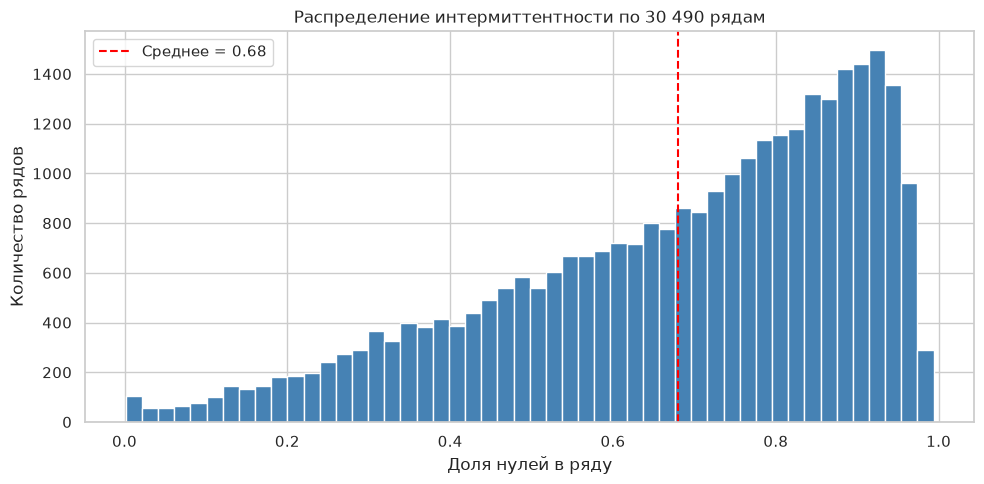

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(zero_ratio_per_row, bins=50, color="steelblue", edgecolor="white")
ax.axvline(zero_ratio_per_row.mean(), color="red", linestyle="--",
           label=f"Среднее = {zero_ratio_per_row.mean():.2f}")
ax.set_xlabel("Доля нулей в ряду")
ax.set_ylabel("Количество рядов")
ax.set_title("Распределение интермиттентности по 30 490 рядам")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Возьмём один ряд с высокой интермиттентностью
intermittent_row = df.iloc[zero_ratio_per_row.argmax()]
item = intermittent_row["item_id"]
store = intermittent_row["store_id"]

print(f"Пример интермиттентного ряда: {item} в {store}")
print(f"Доля нулей: {(intermittent_row[day_cols] == 0).mean():.1%}")
print(f"Всего продаж за 5 лет: {intermittent_row[day_cols].sum()}")
print()

# Сравним с baseline "всегда 0"
actual = intermittent_row[day_cols].values
baseline = np.zeros_like(actual)
mae_baseline = np.mean(np.abs(actual - baseline))

print(f"MAE baseline 'всегда 0': {mae_baseline:.4f}")
print()

# И посмотрим на активный ряд для сравнения
active_row = df.iloc[zero_ratio_per_row.argmin()]
print(f"Пример активного ряда: {active_row['item_id']} в {active_row['store_id']}")
print(f"Доля нулей: {(active_row[day_cols] == 0).mean():.1%}")
print(f"Всего продаж за 5 лет: {active_row[day_cols].sum()}")

actual_active = active_row[day_cols].values
baseline_active = np.zeros_like(actual_active)
mae_active = np.mean(np.abs(actual_active - baseline_active))
print(f"MAE baseline 'всегда 0' для активного ряда: {mae_active:.4f}")

Пример интермиттентного ряда: FOODS_3_778 в CA_2
Доля нулей: 99.4%
Всего продаж за 5 лет: 15

MAE baseline 'всегда 0': 0.0000

Пример активного ряда: FOODS_3_586 в CA_2
Доля нулей: 0.2%
Всего продаж за 5 лет: 64421
MAE baseline 'всегда 0' для активного ряда: 33.0000


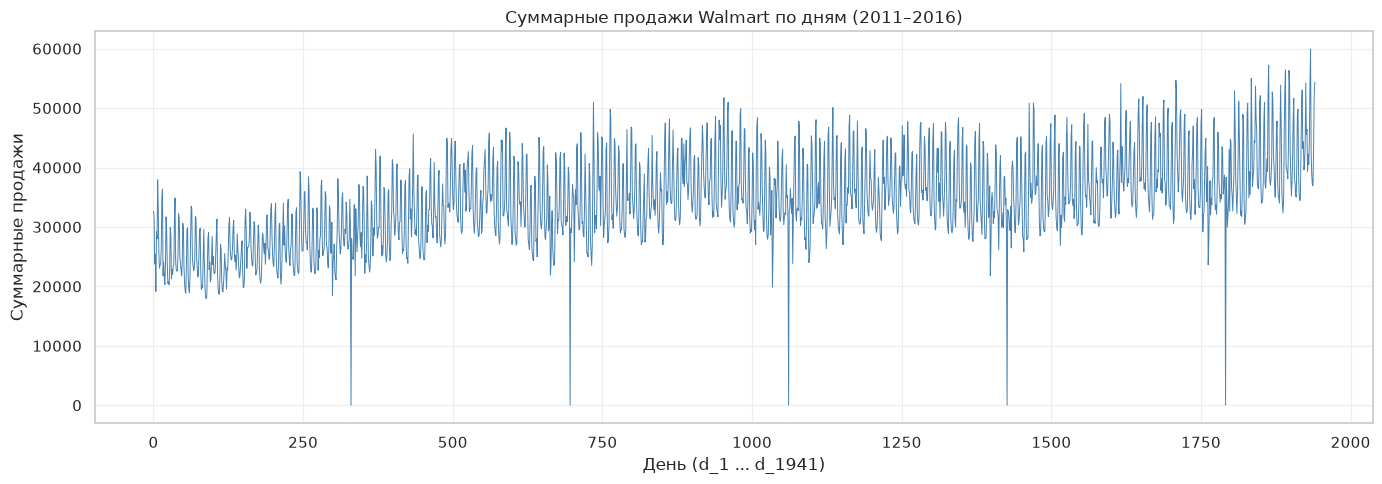

In [17]:
# Сумма продаж по всем рядам за каждый день
daily_total = df[day_cols].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_total.values, linewidth=0.7, color="steelblue")
ax.set_xlabel("День (d_1 ... d_1941)")
ax.set_ylabel("Суммарные продажи")
ax.set_title("Суммарные продажи Walmart по дням (2011–2016)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Дневные колонки
day_cols = df.columns[6:]

# Сумма продаж по каждому магазину за каждый день
store_sales = df.groupby("store_id")[day_cols].sum()

print("Форма таблицы:", store_sales.shape)
print("Строк (магазинов):", store_sales.shape[0])
print("Колонок (дней):", store_sales.shape[1])
print()
print("Первые 5 магазинов, первые 5 дней:")
print(store_sales.iloc[:5, :5])

Форма таблицы: (10, 1941)
Строк (магазинов): 10
Колонок (дней): 1941

Первые 5 магазинов, первые 5 дней:
           d_1   d_2   d_3   d_4   d_5
store_id                              
CA_1      4337  4155  2816  3051  2630
CA_2      3494  3046  2121  2324  1942
CA_3      4739  4827  3785  4232  3817
CA_4      1625  1777  1386  1440  1536
TX_1      2556  2687  1822  2258  1694


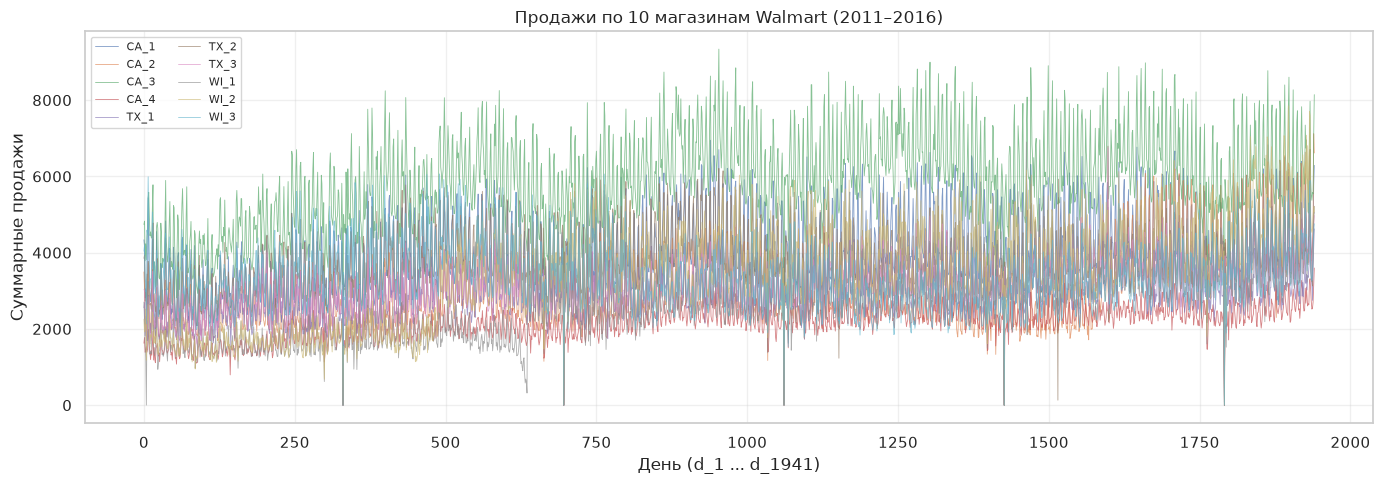

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

for store in store_sales.index:
    ax.plot(store_sales.loc[store].values, linewidth=0.6, alpha=0.7, label=store)

ax.set_xlabel("День (d_1 ... d_1941)")
ax.set_ylabel("Суммарные продажи")
ax.set_title("Продажи по 10 магазинам Walmart (2011–2016)")
ax.legend(loc="upper left", ncol=2, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# По категориям (3: HOBBIES, HOUSEHOLD, FOODS)
cat_sales = df.groupby("cat_id")[day_cols].sum()

# По отделам (7)
dept_sales = df.groupby("dept_id")[day_cols].sum()

# По штатам (3: CA, TX, WI)
state_sales = df.groupby("state_id")[day_cols].sum()

print("Категории:", cat_sales.shape)
print("Отделы:", dept_sales.shape)
print("Штаты:", state_sales.shape)
print()
print("Продажи по категориям за первые 5 дней:")
print(cat_sales.iloc[:, :5])

Категории: (3, 1941)
Отделы: (7, 1941)
Штаты: (3, 1941)

Продажи по категориям за первые 5 дней:
             d_1    d_2    d_3    d_4    d_5
cat_id                                      
FOODS      23178  22758  17174  18878  14603
HOBBIES     3764   3357   2682   2669   1814
HOUSEHOLD   5689   5634   3927   3865   2729


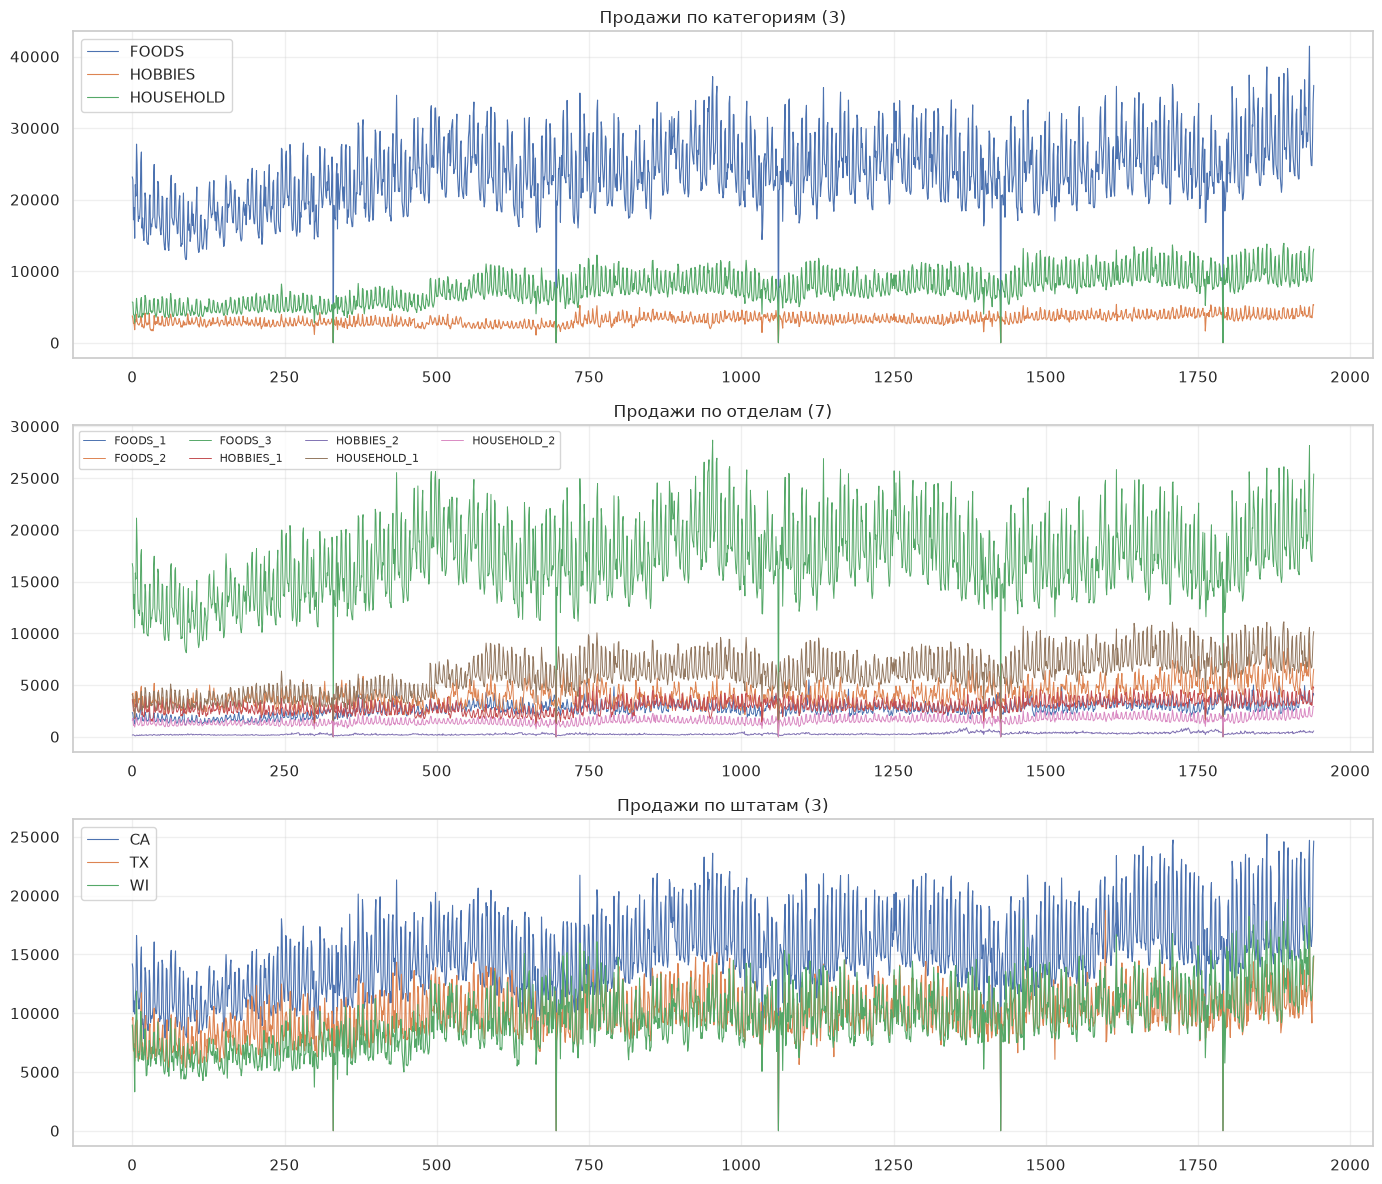

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# По категориям
for cat in cat_sales.index:
    axes[0].plot(cat_sales.loc[cat].values, linewidth=0.8, label=cat)
axes[0].set_title("Продажи по категориям (3)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# По отделам
for dept in dept_sales.index:
    axes[1].plot(dept_sales.loc[dept].values, linewidth=0.7, label=dept)
axes[1].set_title("Продажи по отделам (7)")
axes[1].legend(ncol=4, fontsize=8)
axes[1].grid(alpha=0.3)

# По штатам
for state in state_sales.index:
    axes[2].plot(state_sales.loc[state].values, linewidth=0.8, label=state)
axes[2].set_title("Продажи по штатам (3)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

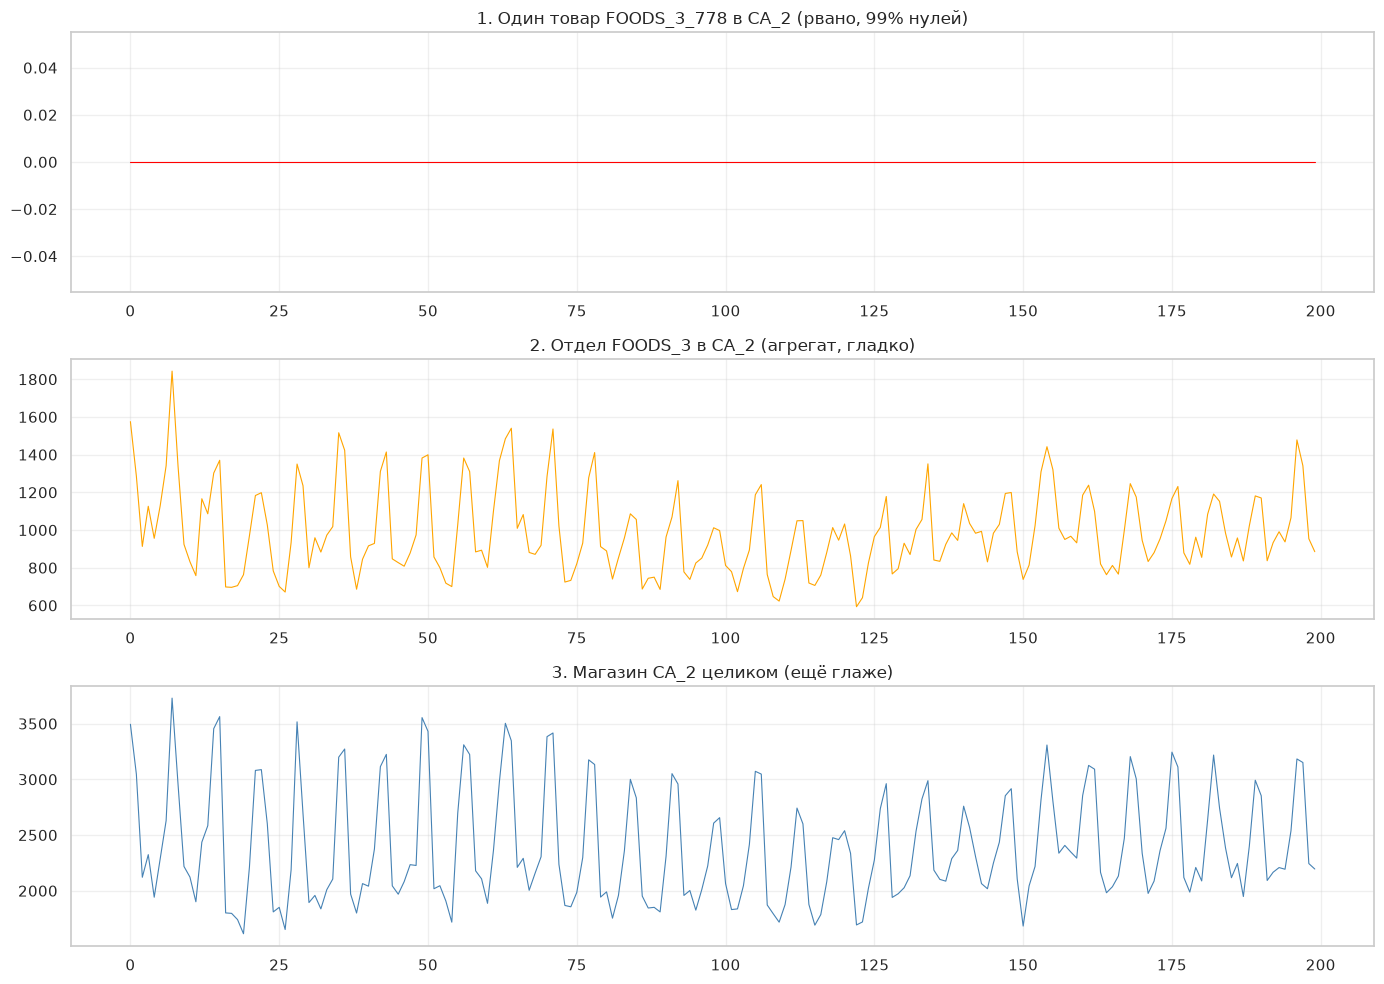

In [22]:
# Один конкретный ряд (интермиттентный)
one_item = df[(df["item_id"] == "FOODS_3_778") & (df["store_id"] == "CA_2")].iloc[0]

# Его отдел в этом же магазине
dept_in_store = df[(df["dept_id"] == "FOODS_3") & (df["store_id"] == "CA_2")][day_cols].sum()

# Магазин целиком
store_total = df[df["store_id"] == "CA_2"][day_cols].sum()

# Рисуем все три уровня
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(one_item[day_cols].values[:200], linewidth=0.8, color="red")
axes[0].set_title("1. Один товар FOODS_3_778 в CA_2 (рвано, 99% нулей)")
axes[0].grid(alpha=0.3)

axes[1].plot(dept_in_store.values[:200], linewidth=0.8, color="orange")
axes[1].set_title("2. Отдел FOODS_3 в CA_2 (агрегат, гладко)")
axes[1].grid(alpha=0.3)

axes[2].plot(store_total.values[:200], linewidth=0.8, color="steelblue")
axes[2].set_title("3. Магазин CA_2 целиком (ещё глаже)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# SNAP — дни продовольственных талонов (по штатам)
# snap_CA = 1 → в этот день в Калифорнии выплачивают талоны

print("Дни SNAP по штатам (сколько дней в году):")
print(calendar[["snap_CA", "snap_TX", "snap_WI"]].sum())
print()
print("Всего дней в календаре:", len(calendar))
print()
print("Доля SNAP-дней:")
print((calendar[["snap_CA", "snap_TX", "snap_WI"]].sum() / len(calendar)).round(3))

Дни SNAP по штатам (сколько дней в году):
snap_CA    650
snap_TX    650
snap_WI    650
dtype: int64

Всего дней в календаре: 1969

Доля SNAP-дней:
snap_CA    0.33
snap_TX    0.33
snap_WI    0.33
dtype: float64


In [24]:
# Берём только SNAP-дни каждого штата
snap_ca = set(calendar[calendar["snap_CA"] == 1]["d"])
snap_tx = set(calendar[calendar["snap_TX"] == 1]["d"])
snap_wi = set(calendar[calendar["snap_WI"] == 1]["d"])

print(f"SNAP-дней в CA: {len(snap_ca)}")
print(f"SNAP-дней в TX: {len(snap_tx)}")
print(f"SNAP-дней в WI: {len(snap_wi)}")
print()
print(f"CA и TX совпадают: {len(snap_ca & snap_tx)} дней")
print(f"CA и WI совпадают: {len(snap_ca & snap_wi)} дней")
print(f"TX и WI совпадают: {len(snap_tx & snap_wi)} дней")
print()
print(f"Все три совпадают: {len(snap_ca & snap_tx & snap_wi)} дней")

SNAP-дней в CA: 650
SNAP-дней в TX: 650
SNAP-дней в WI: 650

CA и TX совпадают: 390 дней
CA и WI совпадают: 390 дней
TX и WI совпадают: 455 дней

Все три совпадают: 260 дней


In [25]:
print("Первые 15 SNAP-дней CA:")
print(sorted(snap_ca)[:15])
print()
print("Первые 15 SNAP-дней TX:")
print(sorted(snap_tx)[:15])
print()
print("Первые 15 SNAP-дней WI:")
print(sorted(snap_wi)[:15])

Первые 15 SNAP-дней CA:
['d_10', 'd_100', 'd_1008', 'd_1009', 'd_101', 'd_1010', 'd_1011', 'd_1012', 'd_1013', 'd_1014', 'd_1015', 'd_1016', 'd_1017', 'd_102', 'd_1038']

Первые 15 SNAP-дней TX:
['d_10', 'd_1008', 'd_101', 'd_1010', 'd_1012', 'd_1013', 'd_1014', 'd_1016', 'd_1018', 'd_1019', 'd_1020', 'd_1022', 'd_103', 'd_1038', 'd_104']

Первые 15 SNAP-дней WI:
['d_100', 'd_1009', 'd_101', 'd_1010', 'd_1012', 'd_1013', 'd_1015', 'd_1016', 'd_1018', 'd_1019', 'd_1021', 'd_1022', 'd_103', 'd_1039', 'd_104']


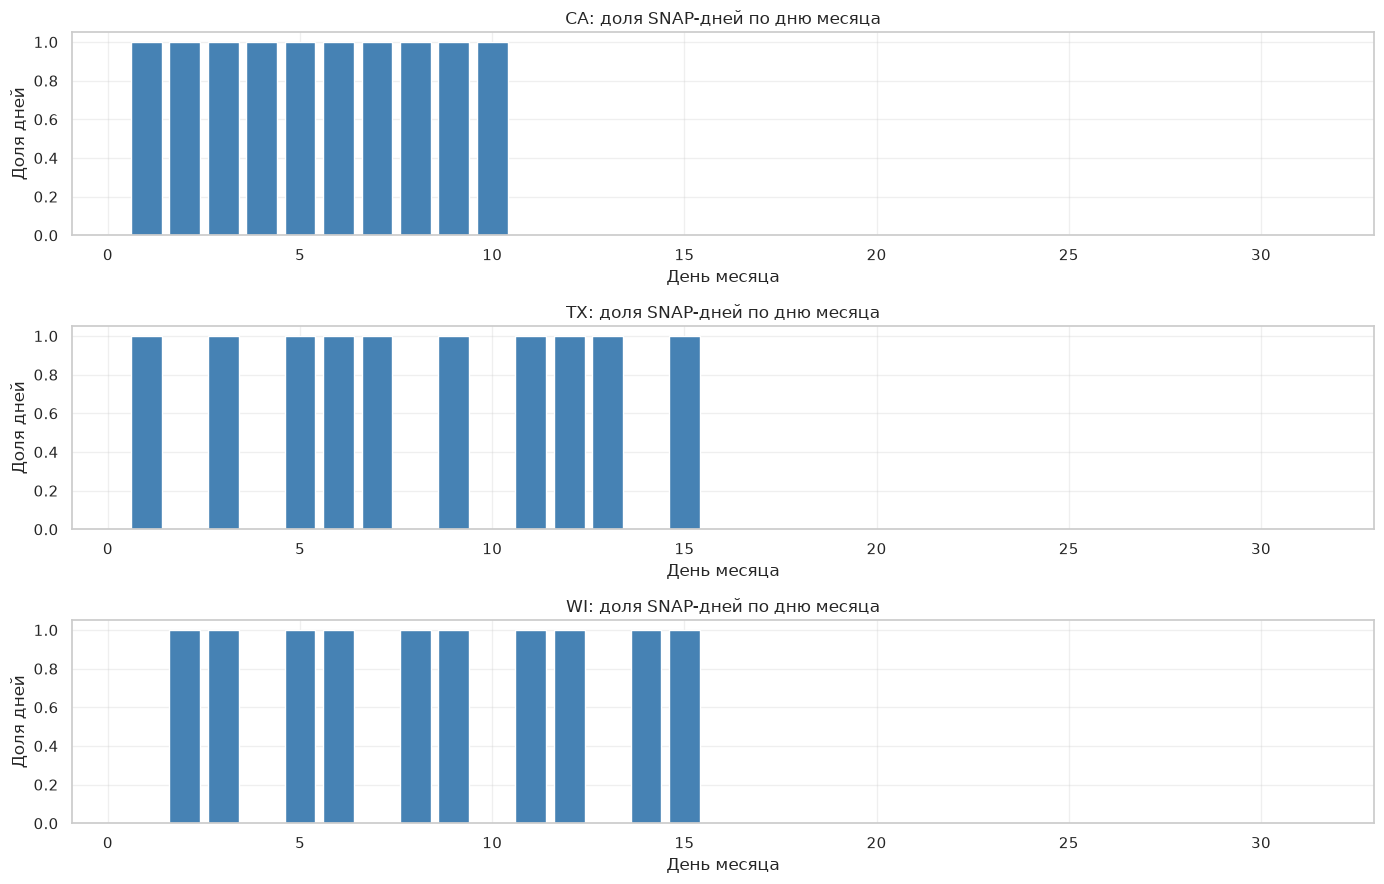

In [26]:
# Разбиваем по дням месяца
calendar["day_of_month"] = pd.to_datetime(calendar["date"]).dt.day

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

for i, state in enumerate(["CA", "TX", "WI"]):
    snap_by_day = calendar.groupby("day_of_month")[f"snap_{state}"].mean()
    axes[i].bar(snap_by_day.index, snap_by_day.values, color="steelblue")
    axes[i].set_title(f"{state}: доля SNAP-дней по дню месяца")
    axes[i].set_xlabel("День месяца")
    axes[i].set_ylabel("Доля дней")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Средние продажи в SNAP-дни и обычные для каждого штата
for state in ["CA", "TX", "WI"]:
    stores = [s for s in store_sales.index if s.startswith(state)]
    state_total = store_sales.loc[stores].sum()
    state_total.index = calendar["d"].values
    
    snap_col = f"snap_{state}"
    snap_mask = calendar.set_index("d")[snap_col] == 1
    
    snap_avg = state_total[snap_mask].mean()
    normal_avg = state_total[~snap_mask].mean()
    
    print(f"{state}:")
    print(f"  SNAP-дни:    {snap_avg:,.0f}")
    print(f"  Обычные:     {normal_avg:,.0f}")
    print(f"  Разница:     {snap_avg - normal_avg:+,.0f} ({(snap_avg/normal_avg - 1):.1%})")
    print()

ValueError: Length mismatch: Expected axis has 1941 elements, new values have 1969 elements

In [28]:
# Доля SNAP-дней у каждого штата
snap_CA_ratio = calendar["snap_CA"].mean()  # 0.33

# Пересечение двух штатов
overlap_CA_TX = ((calendar["snap_CA"] == 1) & (calendar["snap_TX"] == 1)).sum()  # 390

# Все три
overlap_all = ((calendar["snap_CA"] == 1) & (calendar["snap_TX"] == 1) & (calendar["snap_WI"] == 1)).sum()  # 260

In [29]:
import pandas as pd

# 10 дней
df = pd.DataFrame({
    "day": range(1, 11),
    "snap_CA": [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # 1-10
    "snap_TX": [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],  # через день
})

print("Дней SNAP в CA:", df["snap_CA"].sum())  # 10
print("Дней SNAP в TX:", df["snap_TX"].sum())  # 5
print()
print("Совпадают (и CA, и TX):", ((df["snap_CA"] == 1) & (df["snap_TX"] == 1)).sum())  # 5

Дней SNAP в CA: 10
Дней SNAP в TX: 5

Совпадают (и CA, и TX): 5


In [30]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import gc

# Установим LightGBM, если ещё нет
# !pip install lightgbm

ModuleNotFoundError: No module named 'lightgbm'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import gc  # ← работает без установки, встроенный
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

df = pd.read_csv("/app/data/m5/sales_train_evaluation.csv")
calendar = pd.read_csv("/app/data/m5/calendar.csv")
prices = pd.read_csv("/app/data/m5/sell_prices.csv")

print("df:", df.shape)
print("calendar:", calendar.shape)
print("prices:", prices.shape)
print("LightGBM:", lgb.__version__)

df: (30490, 1947)
calendar: (1969, 14)
prices: (6841121, 4)
LightGBM: 4.7.0


In [2]:
N_DAYS = 500
TEST_DAYS = 28

day_cols_short = df.columns[6:6+N_DAYS].tolist()

df_long = df.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    value_vars=day_cols_short,
    var_name="d",
    value_name="sales",
)

df_long["day_num"] = df_long["d"].str.replace("d_", "").astype(int)
df_long["sales"] = df_long["sales"].astype("int16")

print("Long format:", df_long.shape)
print("Память:", df_long.memory_usage(deep=True).sum() / 1e9, "ГБ")

Long format: (15245000, 9)
Память: 2.041087837 ГБ


In [3]:
calendar_small = calendar[[
    "d", "date", "weekday", "wday", "month", "year",
    "snap_CA", "snap_TX", "snap_WI",
    "event_name_1", "event_type_1"
]].copy()
calendar_small["date"] = pd.to_datetime(calendar_small["date"])

df_long = df_long.merge(calendar_small, on="d", how="left")

# Строки → category (экономит память)
for col in ["weekday", "event_name_1", "event_type_1"]:
    df_long[col] = df_long[col].astype("category")

print("После merge:", df_long.shape)
print("Память:", df_long.memory_usage(deep=True).sum() / 1e9, "ГБ")
print()
print(df_long.head())

После merge: (15245000, 19)
Память: 2.940543597 ГБ

                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_evaluation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_evaluation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_evaluation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_evaluation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_evaluation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id    d  sales  day_num       date   weekday  wday  month  year  \
0       CA  d_1      0        1 2011-01-29  Saturday     1      1  2011   
1       CA  d_1      0        1 2011-01-29  Saturday     1      1  2011   
2       CA  d_1      0        1 2011-01-29  Saturday     1      1  2011   
3       CA  d_1      0        1 2011-01-29  Saturday     1      1  2011   
4       CA  d_1      0        1 2011-01-29  Saturday     1      1  2011   

   snap_CA  snap

In [4]:
df_long = df_long.sort_values(["item_id", "store_id", "day_num"]).reset_index(drop=True)

for lag in [1, 7, 28]:
    df_long[f"lag_{lag}"] = (
        df_long.groupby(["item_id", "store_id"])["sales"]
        .shift(lag)
        .astype("float32")
    )

print("С лагами:", df_long.shape)
print("Память:", df_long.memory_usage(deep=True).sum() / 1e9, "ГБ")
print()
print(df_long[["item_id", "store_id", "day_num", "sales", "lag_1", "lag_7", "lag_28"]].head(30))

С лагами: (15245000, 22)
Память: 3.134917347 ГБ

        item_id store_id  day_num  sales  lag_1  lag_7  lag_28
0   FOODS_1_001     CA_1        1      3    NaN    NaN     NaN
1   FOODS_1_001     CA_1        2      0    3.0    NaN     NaN
2   FOODS_1_001     CA_1        3      0    0.0    NaN     NaN
3   FOODS_1_001     CA_1        4      1    0.0    NaN     NaN
4   FOODS_1_001     CA_1        5      4    1.0    NaN     NaN
5   FOODS_1_001     CA_1        6      2    4.0    NaN     NaN
6   FOODS_1_001     CA_1        7      0    2.0    NaN     NaN
7   FOODS_1_001     CA_1        8      2    0.0    3.0     NaN
8   FOODS_1_001     CA_1        9      0    2.0    0.0     NaN
9   FOODS_1_001     CA_1       10      0    0.0    0.0     NaN
10  FOODS_1_001     CA_1       11      0    0.0    1.0     NaN
11  FOODS_1_001     CA_1       12      0    0.0    4.0     NaN
12  FOODS_1_001     CA_1       13      3    0.0    2.0     NaN
13  FOODS_1_001     CA_1       14      1    3.0    0.0     NaN
14  FO

In [5]:
# Сумма продаж отдела в магазине за каждый день
dept_store_sales = df.groupby(["dept_id", "store_id"])[day_cols_short].sum()

print("Форма агрегата:", dept_store_sales.shape)
print()
print("Пример для FOODS_1_CA_1, первые 10 дней:")
print(dept_store_sales.loc[("FOODS_1", "CA_1")].head(10))

Форма агрегата: (70, 500)

Пример для FOODS_1_CA_1, первые 10 дней:
d_1     297
d_2     284
d_3     214
d_4     175
d_5     182
d_6     191
d_7     224
d_8     263
d_9     245
d_10    176
Name: (FOODS_1, CA_1), dtype: int64


In [6]:
# Long format
dept_store_long = dept_store_sales.melt(
    ignore_index=False,
    var_name="d",
    value_name="dept_store_sales",
).reset_index()

# Лаг 7
dept_store_long = dept_store_long.sort_values(["dept_id", "store_id", "d"]).reset_index(drop=True)
dept_store_long["dept_store_lag_7"] = (
    dept_store_long.groupby(["dept_id", "store_id"])["dept_store_sales"]
    .shift(7)
    .astype("float32")
)

print("Агрегат после лага:")
print(dept_store_long[["dept_id", "store_id", "d", "dept_store_sales", "dept_store_lag_7"]].head(15))

Агрегат после лага:
    dept_id store_id      d  dept_store_sales  dept_store_lag_7
0   FOODS_1     CA_1    d_1               297               NaN
1   FOODS_1     CA_1   d_10               176               NaN
2   FOODS_1     CA_1  d_100               211               NaN
3   FOODS_1     CA_1  d_101               175               NaN
4   FOODS_1     CA_1  d_102               162               NaN
5   FOODS_1     CA_1  d_103               135               NaN
6   FOODS_1     CA_1  d_104               167               NaN
7   FOODS_1     CA_1  d_105               179             297.0
8   FOODS_1     CA_1  d_106               274             176.0
9   FOODS_1     CA_1  d_107               204             211.0
10  FOODS_1     CA_1  d_108               170             175.0
11  FOODS_1     CA_1  d_109               158             162.0
12  FOODS_1     CA_1   d_11               217             135.0
13  FOODS_1     CA_1  d_110               177             167.0
14  FOODS_1     CA_1

In [7]:
df_long = df_long.merge(
    dept_store_long[["dept_id", "store_id", "d", "dept_store_lag_7"]],
    on=["dept_id", "store_id", "d"],
    how="left",
)

print("После merge:", df_long.shape)
print("Память:", df_long.memory_usage(deep=True).sum() / 1e9, "ГБ")
print()
print(df_long[["item_id", "dept_id", "store_id", "d", "sales", "lag_7", "dept_store_lag_7"]].head(30))

# Освобождаем память
del dept_store_sales, dept_store_long
gc.collect()

После merge: (15245000, 23)
Память: 3.195897347 ГБ

        item_id  dept_id store_id     d  sales  lag_7  dept_store_lag_7
0   FOODS_1_001  FOODS_1     CA_1   d_1      3    NaN               NaN
1   FOODS_1_001  FOODS_1     CA_1   d_2      0    NaN             162.0
2   FOODS_1_001  FOODS_1     CA_1   d_3      0    NaN             178.0
3   FOODS_1_001  FOODS_1     CA_1   d_4      1    NaN             375.0
4   FOODS_1_001  FOODS_1     CA_1   d_5      4    NaN             205.0
5   FOODS_1_001  FOODS_1     CA_1   d_6      2    NaN             187.0
6   FOODS_1_001  FOODS_1     CA_1   d_7      0    NaN             188.0
7   FOODS_1_001  FOODS_1     CA_1   d_8      2    3.0             144.0
8   FOODS_1_001  FOODS_1     CA_1   d_9      0    0.0             183.0
9   FOODS_1_001  FOODS_1     CA_1  d_10      0    0.0               NaN
10  FOODS_1_001  FOODS_1     CA_1  d_11      0    1.0             135.0
11  FOODS_1_001  FOODS_1     CA_1  d_12      0    4.0             178.0
12  FOODS_1_

0

In [8]:
# Считаем агрегат
dept_store_sales = df.groupby(["dept_id", "store_id"])[day_cols_short].sum()

# Long format
dept_store_long = dept_store_sales.melt(
    ignore_index=False, var_name="d", value_name="dept_store_sales",
).reset_index()

# ⚠️ ВАЖНО: добавляем числовой номер дня
dept_store_long["day_num"] = dept_store_long["d"].str.replace("d_", "").astype(int)

# Сортируем по ЧИСЛУ, не по строке
dept_store_long = dept_store_long.sort_values(["dept_id", "store_id", "day_num"]).reset_index(drop=True)

# Лаг 7
dept_store_long["dept_store_lag_7"] = (
    dept_store_long.groupby(["dept_id", "store_id"])["dept_store_sales"]
    .shift(7)
    .astype("float32")
)

print("Проверка сортировки — первые 15 дней FOODS_1 CA_1:")
print(dept_store_long[dept_store_long["dept_id"] == "FOODS_1"][
    ["d", "day_num", "dept_store_sales", "dept_store_lag_7"]
].head(15))

Проверка сортировки — первые 15 дней FOODS_1 CA_1:
       d  day_num  dept_store_sales  dept_store_lag_7
0    d_1        1               297               NaN
1    d_2        2               284               NaN
2    d_3        3               214               NaN
3    d_4        4               175               NaN
4    d_5        5               182               NaN
5    d_6        6               191               NaN
6    d_7        7               224               NaN
7    d_8        8               263             297.0
8    d_9        9               245             284.0
9   d_10       10               176             214.0
10  d_11       11               217             175.0
11  d_12       12               156             182.0
12  d_13       13               242             191.0
13  d_14       14               327             224.0
14  d_15       15               409             263.0


In [9]:
df_long = df_long.drop(columns=["dept_store_lag_7"])

In [10]:
df_long = df_long.merge(
    dept_store_long[["dept_id", "store_id", "d", "dept_store_lag_7"]],
    on=["dept_id", "store_id", "d"], how="left",
)

print("После merge:", df_long.shape)
print(df_long[["item_id", "d", "sales", "lag_7", "dept_store_lag_7"]].head(15))

После merge: (15245000, 23)
        item_id     d  sales  lag_7  dept_store_lag_7
0   FOODS_1_001   d_1      3    NaN               NaN
1   FOODS_1_001   d_2      0    NaN               NaN
2   FOODS_1_001   d_3      0    NaN               NaN
3   FOODS_1_001   d_4      1    NaN               NaN
4   FOODS_1_001   d_5      4    NaN               NaN
5   FOODS_1_001   d_6      2    NaN               NaN
6   FOODS_1_001   d_7      0    NaN               NaN
7   FOODS_1_001   d_8      2    3.0             297.0
8   FOODS_1_001   d_9      0    0.0             284.0
9   FOODS_1_001  d_10      0    0.0             214.0
10  FOODS_1_001  d_11      0    1.0             175.0
11  FOODS_1_001  d_12      0    4.0             182.0
12  FOODS_1_001  d_13      3    2.0             191.0
13  FOODS_1_001  d_14      1    0.0             224.0
14  FOODS_1_001  d_15      3    2.0             263.0


In [11]:
print("Строк до:", len(df_long))
print("Память:", df_long.memory_usage(deep=True).sum() / 1e9, "ГБ")
print()

df_model = df_long.dropna().reset_index(drop=True)

print("Строк после:", len(df_model))
print("Удалено:", len(df_long) - len(df_model), 
      f"({(len(df_long) - len(df_model))/len(df_long):.2%})")
print("Память:", df_model.memory_usage(deep=True).sum() / 1e9, "ГБ")

# Освобождаем память
del df_long
gc.collect()

Строк до: 15245000
Память: 3.195897347 ГБ

Строк после: 1189110
Удалено: 14055890 (92.20%)
Память: 0.249324235 ГБ


0

In [12]:
# Заново melt
N_DAYS = 500
TEST_DAYS = 28
day_cols_short = df.columns[6:6+N_DAYS].tolist()

df_long = df.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    value_vars=day_cols_short,
    var_name="d",
    value_name="sales",
)
df_long["day_num"] = df_long["d"].str.replace("d_", "").astype(int)
df_long["sales"] = df_long["sales"].astype("int16")

# ⚠️ ВАЖНО: календарь БЕЗ event_name_1
calendar_small = calendar[[
    "d", "date", "weekday", "wday", "month", "year",
    "snap_CA", "snap_TX", "snap_WI",
    # "event_name_1", "event_type_1"  ← УБРАЛИ
]].copy()
calendar_small["date"] = pd.to_datetime(calendar_small["date"])

df_long = df_long.merge(calendar_small, on="d", how="left")

for col in ["weekday"]:
    df_long[col] = df_long[col].astype("category")

print("После merge:", df_long.shape)
print("Память:", df_long.memory_usage(deep=True).sum() / 1e9, "ГБ")

После merge: (15245000, 17)
Память: 2.910052944 ГБ


In [13]:
df_long = df_long.sort_values(["item_id", "store_id", "day_num"]).reset_index(drop=True)

for lag in [1, 7, 28]:
    df_long[f"lag_{lag}"] = (
        df_long.groupby(["item_id", "store_id"])["sales"]
        .shift(lag)
        .astype("float32")
    )

print("С лагами:", df_long.shape)

С лагами: (15245000, 20)


In [14]:
# Считаем агрегат
dept_store_sales = df.groupby(["dept_id", "store_id"])[day_cols_short].sum()

dept_store_long = dept_store_sales.melt(
    ignore_index=False, var_name="d", value_name="dept_store_sales",
).reset_index()

# ⚠️ Сортируем по ЧИСЛУ
dept_store_long["day_num"] = dept_store_long["d"].str.replace("d_", "").astype(int)
dept_store_long = dept_store_long.sort_values(
    ["dept_id", "store_id", "day_num"]
).reset_index(drop=True)

dept_store_long["dept_store_lag_7"] = (
    dept_store_long.groupby(["dept_id", "store_id"])["dept_store_sales"]
    .shift(7)
    .astype("float32")
)

df_long = df_long.merge(
    dept_store_long[["dept_id", "store_id", "d", "dept_store_lag_7"]],
    on=["dept_id", "store_id", "d"], how="left",
)

print("С агрегатами:", df_long.shape)

del dept_store_sales, dept_store_long
gc.collect()

С агрегатами: (15245000, 21)


0

In [ ]:
print("Строк до:", len(df_long))
print("Память:", df_long.memory_usage(deep=True).sum() / 1e9, "ГБ")

df_model = df_long.dropna().reset_index(drop=True)

print("Строк после:", len(df_model))
print("Удалено:", len(df_long) - len(df_model),
      f"({(len(df_long) - len(df_model))/len(df_long):.2%})")
print("Память:", df_model.memory_usage(deep=True).sum() / 1e9, "ГБ")

del df_long
gc.collect()

Строк до: 15245000
Память: 3.165406694 ГБ


In [1]:
# ===== ИМПОРТЫ =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import gc
from sklearn.metrics import mean_absolute_error

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# ===== ЗАГРУЗКА =====
df = pd.read_csv("/app/data/m5/sales_train_evaluation.csv")
calendar = pd.read_csv("/app/data/m5/calendar.csv")

# ⚠️ УМЕНЬШИЛИ ДНИ
N_DAYS = 300
TEST_DAYS = 28
day_cols_short = df.columns[6:6+N_DAYS].tolist()

# ===== MELT =====
df_long = df.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    value_vars=day_cols_short,
    var_name="d",
    value_name="sales",
)
df_long["day_num"] = df_long["d"].str.replace("d_", "").astype(int)
df_long["sales"] = df_long["sales"].astype("int16")

# ===== МЕРЖ С КАЛЕНДАРЁМ (без event_name_1) =====
calendar_small = calendar[["d", "wday", "month", "snap_CA", "snap_TX", "snap_WI"]].copy()
df_long = df_long.merge(calendar_small, on="d", how="left")

# ===== ОПТИМИЗАЦИЯ ТИПОВ =====
df_long = df_long.drop(columns=["id"])
for col in ["item_id", "dept_id", "cat_id", "store_id", "state_id"]:
    df_long[col] = df_long[col].astype("category")
df_long["wday"] = df_long["wday"].astype("int8")
df_long["month"] = df_long["month"].astype("int8")
for col in ["snap_CA", "snap_TX", "snap_WI"]:
    df_long[col] = df_long[col].astype("int8")

# Убираем промежуточные
del calendar_small
gc.collect()
print("После melt + merge:", df_long.shape, "|", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")

# ===== ЛАГИ =====
df_long = df_long.sort_values(["item_id", "store_id", "day_num"]).reset_index(drop=True)
for lag in [1, 7, 28]:
    df_long[f"lag_{lag}"] = (
        df_long.groupby(["item_id", "store_id"], observed=True)["sales"]
        .shift(lag).astype("float32")
    )

gc.collect()
print("После лагов:", df_long.shape, "|", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")

# ===== АГРЕГАТ ПО ОТДЕЛУ =====
dept_store_sales = df.groupby(["dept_id", "store_id"])[day_cols_short].sum()
dept_store_long = dept_store_sales.melt(
    ignore_index=False, var_name="d", value_name="dept_store_sales",
).reset_index()
dept_store_long["day_num"] = dept_store_long["d"].str.replace("d_", "").astype(int)
dept_store_long = dept_store_long.sort_values(
    ["dept_id", "store_id", "day_num"]
).reset_index(drop=True)
dept_store_long["dept_store_lag_7"] = (
    dept_store_long.groupby(["dept_id", "store_id"], observed=True)["dept_store_sales"]
    .shift(7).astype("float32")
)

df_long = df_long.merge(
    dept_store_long[["dept_id", "store_id", "d", "dept_store_lag_7"]],
    on=["dept_id", "store_id", "d"], how="left",
)

del dept_store_sales, dept_store_long
gc.collect()
print("С агрегатом:", df_long.shape, "|", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")

# ===== УДАЛЯЕМ NaN INPLACE =====
print()
print("Строк до dropna:", len(df_long))
df_long.dropna(inplace=True)
df_long.reset_index(drop=True, inplace=True)
print("Строк после dropna:", len(df_long))
print("Удалено:", f"{(1 - len(df_long) / (30490 * N_DAYS)):.2%}")
print("Память:", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")
print()
print("Пропуски:", df_long.isna().sum().sum())
print()
print(df_long.head(15))

После melt + merge: (9147000, 13) | 0.31 ГБ
После лагов: (9147000, 16) | 0.42 ГБ
С агрегатом: (9147000, 17) | 0.7 ГБ

Строк до dropna: 9147000
Строк после dropna: 8293280
Удалено: 9.33%
Память: 0.64 ГБ

Пропуски: 0

        item_id  dept_id cat_id store_id state_id     d  sales  day_num  wday  \
0   FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_29      2       29     1   
1   FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_30      2       30     2   
2   FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_31      0       31     3   
3   FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_32      2       32     4   
4   FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_33      1       33     5   
5   FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_34      7       34     6   
6   FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_35      1       35     7   
7   FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_36      2       36     1   
8   FOODS_1_001  FOODS_1  FOODS     CA_1       CA  d_37

In [2]:
train = df_long[df_long["day_num"] <= 300 - 28].copy()
test  = df_long[df_long["day_num"] >  300 - 28].copy()

print("Train:", train.shape)
print("Test: ", test.shape)
print()
print(f"Train: дни {train['day_num'].min()} ... {train['day_num'].max()}")
print(f"Test:  дни {test['day_num'].min()} ... {test['day_num'].max()}")
print()
print("Baseline MAE (всегда 0):", mean_absolute_error(test['sales'], [0]*len(test)))

Train: (7439560, 17)
Test:  (853720, 17)

Train: дни 29 ... 272
Test:  дни 273 ... 300

Baseline MAE (всегда 0): 0.9326933889331397


In [3]:
features = [
    "lag_1", "lag_7", "lag_28", "dept_store_lag_7",
    "wday", "month", "snap_CA", "snap_TX", "snap_WI",
    "item_id", "dept_id", "cat_id", "store_id", "state_id",
]
cat_features = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]

X_train, y_train = train[features], train["sales"]
X_test, y_test = test[features], test["sales"]

model = lgb.LGBMRegressor(
    objective="tweedie",
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train, categorical_feature=cat_features)

preds = model.predict(X_test)
preds = np.maximum(preds, 0)

mae = mean_absolute_error(y_test, preds)
baseline_mae = mean_absolute_error(y_test, [0]*len(y_test))

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Model MAE:    {mae:.4f}")
print(f"Улучшение:    {1 - mae/baseline_mae:.1%}")

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: dept_id: str, store_id: str

In [4]:
features = [
    "lag_1", "lag_7", "lag_28", "dept_store_lag_7",
    "wday", "month", "snap_CA", "snap_TX", "snap_WI",
    "item_id", "dept_id", "cat_id", "store_id", "state_id",
]
cat_features = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]

X_train, y_train = train[features], train["sales"]
X_test, y_test = test[features], test["sales"]

model = lgb.LGBMRegressor(
    objective="tweedie",
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train, categorical_feature=cat_features)

preds = model.predict(X_test)
preds = np.maximum(preds, 0)

mae = mean_absolute_error(y_test, preds)
baseline_mae = mean_absolute_error(y_test, [0]*len(y_test))

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Model MAE:    {mae:.4f}")
print(f"Улучшение:    {1 - mae/baseline_mae:.1%}")

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: dept_id: str, store_id: str

In [5]:
# Преобразуем категориальные в int коды
for col in ["item_id", "dept_id", "cat_id", "store_id", "state_id"]:
    df_long[col] = df_long[col].astype("category").cat.codes.astype("int32")

print("Типы после конвертации:")
print(df_long[["item_id", "dept_id", "cat_id", "store_id", "state_id"]].dtypes)
print()
print(df_long[["item_id", "dept_id", "cat_id", "store_id", "state_id"]].head())

Типы после конвертации:
item_id     int32
dept_id     int32
cat_id      int32
store_id    int32
state_id    int32
dtype: object

   item_id  dept_id  cat_id  store_id  state_id
0        0        0       0         0         0
1        0        0       0         0         0
2        0        0       0         0         0
3        0        0       0         0         0
4        0        0       0         0         0


In [6]:
train = df_long[df_long["day_num"] <= 300 - 28].copy()
test  = df_long[df_long["day_num"] >  300 - 28].copy()

print("Train:", train.shape)
print("Test: ", test.shape)
print()
print("Типы признаков:")
for col in ["item_id", "dept_id", "cat_id", "store_id", "state_id"]:
    print(f"  {col}: {train[col].dtype}")

Train: (7439560, 17)
Test:  (853720, 17)

Типы признаков:
  item_id: int32
  dept_id: int32
  cat_id: int32
  store_id: int32
  state_id: int32


In [7]:
features = [
    "lag_1", "lag_7", "lag_28", "dept_store_lag_7",
    "wday", "month", "snap_CA", "snap_TX", "snap_WI",
    "item_id", "dept_id", "cat_id", "store_id", "state_id",
]
cat_features = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]

X_train, y_train = train[features], train["sales"]
X_test, y_test = test[features], test["sales"]

model = lgb.LGBMRegressor(
    objective="tweedie",
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train, categorical_feature=cat_features)

preds = model.predict(X_test)
preds = np.maximum(preds, 0)

mae = mean_absolute_error(y_test, preds)
baseline_mae = mean_absolute_error(y_test, [0]*len(y_test))

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Model MAE:    {mae:.4f}")
print(f"Улучшение:    {1 - mae/baseline_mae:.1%}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.576709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3568
[LightGBM] [Info] Number of data points in the train set: 7439560, number of used features: 14
[LightGBM] [Info] Start training from score -0.166759
Baseline MAE: 0.9327
Model MAE:    0.6576
Улучшение:    29.5%


         feature  importance
         item_id        4887
           lag_1         247
           lag_7         241
          lag_28         220
         dept_id         117
dept_store_lag_7          90
        store_id          86
            wday          40
           month          30
         snap_TX          20
          cat_id          14
         snap_CA           6
         snap_WI           1
        state_id           1


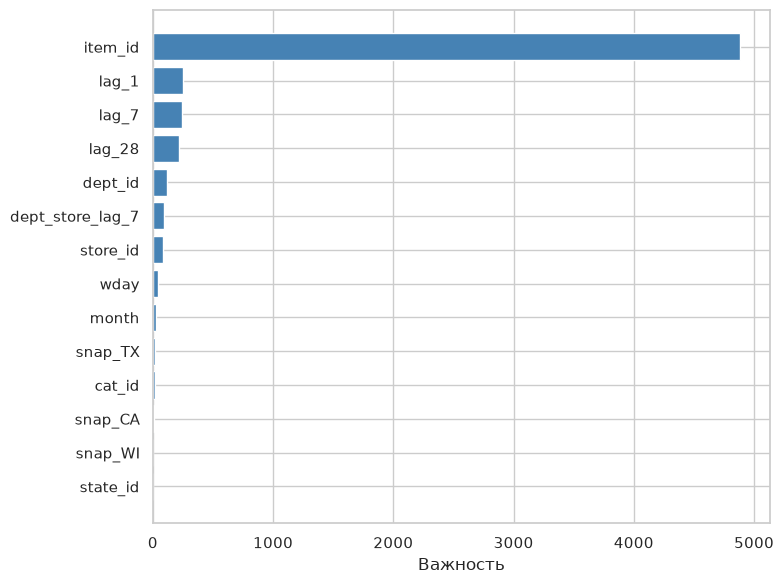

In [8]:
importances = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

print(importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances["feature"], importances["importance"], color="steelblue")
ax.set_xlabel("Важность")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
features = [
    "lag_1", "lag_7", "lag_28", "dept_store_lag_7",
    "wday", "month", "snap_CA", "snap_TX", "snap_WI",
    "dept_id", "cat_id", "store_id", "state_id",
    # item_id убрали!
]
cat_features = ["dept_id", "cat_id", "store_id", "state_id"]

X_train, y_train = train[features], train["sales"]
X_test, y_test = test[features], test["sales"]

model2 = lgb.LGBMRegressor(
    objective="tweedie",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
)

model2.fit(X_train, y_train, categorical_feature=cat_features)

preds2 = np.maximum(model2.predict(X_test), 0)
mae2 = mean_absolute_error(y_test, preds2)

print(f"Model (без item_id) MAE: {mae2:.4f}")
print(f"Улучшение:               {1 - mae2/0.9327:.1%}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.750348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 561
[LightGBM] [Info] Number of data points in the train set: 7439560, number of used features: 13
[LightGBM] [Info] Start training from score -0.166759
Model (без item_id) MAE: 0.6688
Улучшение:               28.3%


         feature  importance
dept_store_lag_7        3878
          lag_28        2100
        store_id        2096
           lag_7        1926
           lag_1        1842
           month        1717
            wday        1540
         dept_id        1419
         snap_TX         458
         snap_CA         455
          cat_id         439
         snap_WI         384
        state_id         346


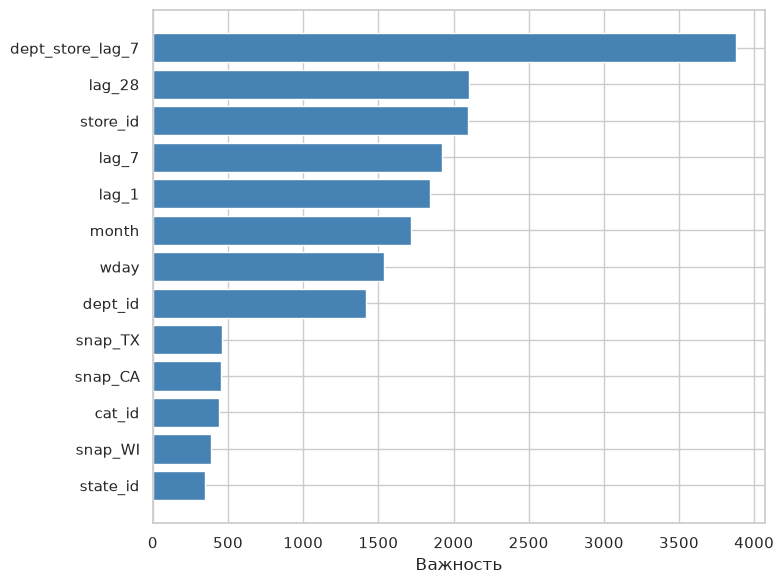

In [10]:
importances2 = pd.DataFrame({
    "feature": features,
    "importance": model2.feature_importances_,
}).sort_values("importance", ascending=False)

print(importances2.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importances2["feature"], importances2["importance"], color="steelblue")
ax.set_xlabel("Важность")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
# Сортируем для группировки
df_long = df_long.sort_values(["item_id", "store_id", "day_num"]).reset_index(drop=True)

# Rolling-средние по товару
df_long["rolling_7"] = (
    df_long.groupby(["item_id", "store_id"], observed=True)["sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
    .astype("float32")
)

df_long["rolling_28"] = (
    df_long.groupby(["item_id", "store_id"], observed=True)["sales"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
    .astype("float32")
)

# Дополнительные лаги
for lag in [14, 21]:
    df_long[f"lag_{lag}"] = (
        df_long.groupby(["item_id", "store_id"], observed=True)["sales"]
        .shift(lag).astype("float32")
    )

gc.collect()
print("С rolling и новыми лагами:", df_long.shape, "|", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")

С rolling и новыми лагами: (8293280, 21) | 0.66 ГБ


In [12]:
train = df_long[df_long["day_num"] <= 300 - 28].copy()
test  = df_long[df_long["day_num"] >  300 - 28].copy()

# Убираем NaN после rolling
train = train.dropna(subset=["rolling_7", "rolling_28", "lag_14", "lag_21"]).reset_index(drop=True)
test  = test.dropna(subset=["rolling_7", "rolling_28", "lag_14", "lag_21"]).reset_index(drop=True)

print("Train:", train.shape)
print("Test: ", test.shape)

Train: (6585840, 21)
Test:  (853720, 21)


In [13]:
features = [
    "lag_1", "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_7", "rolling_28",
    "dept_store_lag_7",
    "wday", "month", "snap_CA", "snap_TX", "snap_WI",
    "dept_id", "cat_id", "store_id", "state_id",
]
cat_features = ["dept_id", "cat_id", "store_id", "state_id"]

X_train, y_train = train[features], train["sales"]
X_test, y_test = test[features], test["sales"]

model3 = lgb.LGBMRegressor(
    objective="tweedie",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
)

model3.fit(X_train, y_train, categorical_feature=cat_features)

preds3 = np.maximum(model3.predict(X_test), 0)
mae3 = mean_absolute_error(y_test, preds3)

print(f"Model MAE:    {mae3:.4f}")
print(f"Улучшение:    {1 - mae3/0.9327:.1%}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.556209 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1232
[LightGBM] [Info] Number of data points in the train set: 6585840, number of used features: 17
[LightGBM] [Info] Start training from score -0.163114
Model MAE:    0.6036
Улучшение:    35.3%


         feature  importance
dept_store_lag_7        4127
      rolling_28        2087
            wday        2058
           month        1911
        store_id        1732
       rolling_7        1256
         dept_id         915
           lag_1         848
         snap_CA         549
          lag_28         481
         snap_TX         479
         snap_WI         423
          lag_14         391
          cat_id         389
          lag_21         355
        state_id         332
           lag_7         267


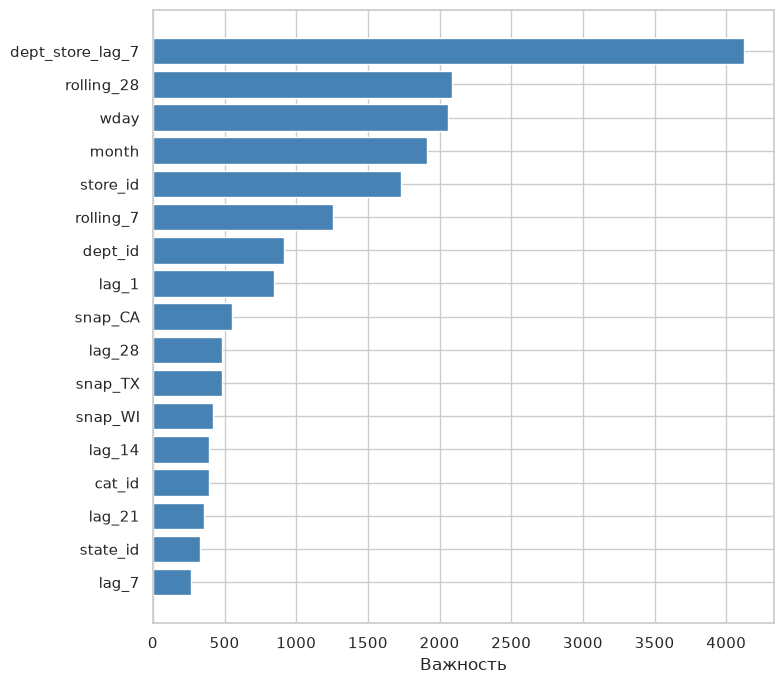

In [14]:
importances3 = pd.DataFrame({
    "feature": features,
    "importance": model3.feature_importances_,
}).sort_values("importance", ascending=False)

print(importances3.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importances3["feature"], importances3["importance"], color="steelblue")
ax.set_xlabel("Важность")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
# 1. Rolling_14
df_long["rolling_14"] = (
    df_long.groupby(["item_id", "store_id"], observed=True)["sales"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
    .astype("float32")
)

# 2. Праздники — флаг is_event
calendar["is_event"] = calendar["event_name_1"].notna().astype("int8")
calendar_small = calendar[["d", "is_event"]]
df_long = df_long.merge(calendar_small, on="d", how="left")

gc.collect()
print("После rolling_14 + is_event:", df_long.shape, "|", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")

После rolling_14 + is_event: (8293280, 23) | 0.7 ГБ


In [16]:
train = df_long[df_long["day_num"] <= 300 - 28].copy()
test  = df_long[df_long["day_num"] >  300 - 28].copy()

train = train.dropna(subset=["rolling_14"]).reset_index(drop=True)
test  = test.dropna(subset=["rolling_14"]).reset_index(drop=True)

print("Train:", train.shape)
print("Test: ", test.shape)

Train: (7012700, 23)
Test:  (853720, 23)


In [17]:
features = [
    "lag_1", "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_7", "rolling_14", "rolling_28",
    "dept_store_lag_7",
    "wday", "month", "is_event",
    "snap_CA", "snap_TX", "snap_WI",
    "dept_id", "cat_id", "store_id", "state_id",
]
cat_features = ["dept_id", "cat_id", "store_id", "state_id"]

X_train, y_train = train[features], train["sales"]
X_test, y_test = test[features], test["sales"]

model4 = lgb.LGBMRegressor(
    objective="tweedie",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
)

model4.fit(X_train, y_train, categorical_feature=cat_features)

preds4 = np.maximum(model4.predict(X_test), 0)
mae4 = mean_absolute_error(y_test, preds4)

print(f"Model v4 MAE: {mae4:.4f}")
print(f"Улучшение:    {1 - mae4/0.9327:.1%}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.636189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1488
[LightGBM] [Info] Number of data points in the train set: 7012700, number of used features: 19
[LightGBM] [Info] Start training from score -0.165862
Model v4 MAE: 0.6041
Улучшение:    35.2%


         feature  importance
dept_store_lag_7        3898
      rolling_28        2007
            wday        1971
        store_id        1711
           month        1660
       rolling_7        1056
      rolling_14         937
         dept_id         917
           lag_1         818
          lag_28         497
         snap_CA         467
         snap_TX         431
          lag_21         404
         snap_WI         381
          cat_id         376
        state_id         340
          lag_14         282
           lag_7         226
        is_event         221


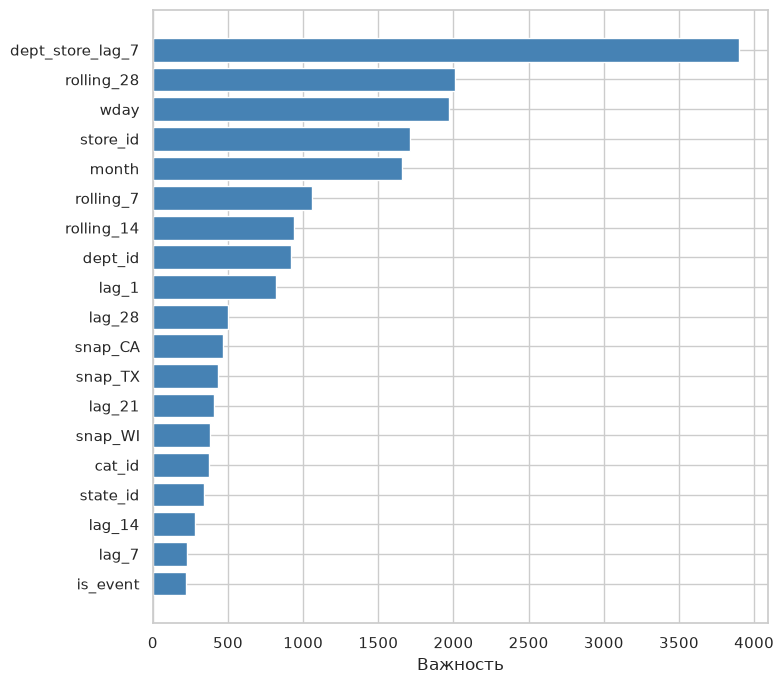

In [18]:
importances4 = pd.DataFrame({
    "feature": features,
    "importance": model4.feature_importances_,
}).sort_values("importance", ascending=False)

print(importances4.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importances4["feature"], importances4["importance"], color="steelblue")
ax.set_xlabel("Важность")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
# Убираем лишние колонки
cols_to_drop = ["rolling_14", "is_event"]
df_long = df_long.drop(columns=[c for c in cols_to_drop if c in df_long.columns])

gc.collect()
print("После удаления:", df_long.shape)
print("Память:", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")
print()
print("Колонки:", df_long.columns.tolist())

После удаления: (8293280, 21)
Память: 0.66 ГБ

Колонки: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'day_num', 'wday', 'month', 'snap_CA', 'snap_TX', 'snap_WI', 'lag_1', 'lag_7', 'lag_28', 'dept_store_lag_7', 'rolling_7', 'rolling_28', 'lag_14', 'lag_21']


In [20]:
train = df_long[df_long["day_num"] <= 300 - 28].copy()
test  = df_long[df_long["day_num"] >  300 - 28].copy()

# Убираем NaN после rolling
train = train.dropna(subset=["rolling_7", "rolling_28"]).reset_index(drop=True)
test  = test.dropna(subset=["rolling_7", "rolling_28"]).reset_index(drop=True)

print("Train:", train.shape)
print("Test: ", test.shape)

Train: (6585840, 21)
Test:  (853720, 21)


In [21]:
features_v3 = [
    "lag_1", "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_7", "rolling_28",
    "dept_store_lag_7",
    "wday", "month",
    "snap_CA", "snap_TX", "snap_WI",
    "dept_id", "cat_id", "store_id", "state_id",
]
cat_features = ["dept_id", "cat_id", "store_id", "state_id"]

X_train, y_train = train[features_v3], train["sales"]
X_test, y_test = test[features_v3], test["sales"]

model_v3 = lgb.LGBMRegressor(
    objective="tweedie",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
)

model_v3.fit(X_train, y_train, categorical_feature=cat_features)

preds_v3 = np.maximum(model_v3.predict(X_test), 0)
mae_v3 = mean_absolute_error(y_test, preds_v3)

print(f"Model v3 MAE: {mae_v3:.4f}")
print(f"Улучшение:    {1 - mae_v3/0.9327:.1%}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.527950 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1232
[LightGBM] [Info] Number of data points in the train set: 6585840, number of used features: 17
[LightGBM] [Info] Start training from score -0.163114
Model v3 MAE: 0.6036
Улучшение:    35.3%


In [22]:
prices = pd.read_csv("/app/data/m5/sell_prices.csv")
print("prices:", prices.shape)
print(prices.head())
print()
print("Уникальных недель:", prices["wm_yr_wk"].nunique())
print("Диапазон недель:", prices["wm_yr_wk"].min(), "–", prices["wm_yr_wk"].max())

prices: (6841121, 4)
  store_id        item_id  wm_yr_wk  sell_price
0     CA_1  HOBBIES_1_001     11325        9.58
1     CA_1  HOBBIES_1_001     11326        9.58
2     CA_1  HOBBIES_1_001     11327        8.26
3     CA_1  HOBBIES_1_001     11328        8.26
4     CA_1  HOBBIES_1_001     11329        8.26

Уникальных недель: 282
Диапазон недель: 11101 – 11621


In [23]:
# В calendar есть связка d → wm_yr_wk
calendar_days = calendar[["d", "wm_yr_wk"]].copy()

# Добавляем wm_yr_wk в df_long
df_long = df_long.merge(calendar_days, on="d", how="left")

gc.collect()
print("После merge с calendar_days:", df_long.shape)
print("Память:", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")

После merge с calendar_days: (8293280, 22)
Память: 0.73 ГБ


In [24]:
# Мерджим цены по (store_id, item_id, wm_yr_wk)
# ⚠️ item_id и store_id в df_long уже закодированы числами!
# Нужно расшифровать обратно для мерджа.

# Сохраняем маппинг
item_codes = df["item_id"].astype("category").cat.categories
store_codes = df["store_id"].astype("category").cat.categories

# Расшифровываем
df_long["item_id_str"] = item_codes[df_long["item_id"]]
df_long["store_id_str"] = store_codes[df_long["store_id"]]

gc.collect()
print("После декодирования:", df_long.shape)

# Мерджим
df_long = df_long.merge(
    prices.rename(columns={"item_id": "item_id_str", "store_id": "store_id_str"}),
    on=["store_id_str", "item_id_str", "wm_yr_wk"],
    how="left",
)

# Убираем строковые обратно
df_long = df_long.drop(columns=["item_id_str", "store_id_str"])

gc.collect()
print("После merge с prices:", df_long.shape)
print("Память:", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")
print()
print("Пропуски в sell_price:", df_long["sell_price"].isna().sum())

После декодирования: (8293280, 24)
После merge с prices: (8293280, 23)
Память: 0.8 ГБ

Пропуски в sell_price: 4137872


In [25]:
# Пропуски — товар не продавался в этом магазине на этой неделе
# Заполняем медианой по товару-магазину
price_median = df_long.groupby(["item_id", "store_id"], observed=True)["sell_price"].transform("median")
df_long["sell_price"] = df_long["sell_price"].fillna(price_median)
df_long["sell_price"] = df_long["sell_price"].fillna(0)  # если всё ещё NaN

print("Пропуски в sell_price после заполнения:", df_long["sell_price"].isna().sum())

gc.collect()

Пропуски в sell_price после заполнения: 0


0

In [26]:
# Пересобираем train/test С ценами
train = df_long[df_long["day_num"] <= 300 - 28].copy()
test  = df_long[df_long["day_num"] >  300 - 28].copy()

train = train.dropna(subset=["rolling_7", "rolling_28", "sell_price"]).reset_index(drop=True)
test  = test.dropna(subset=["rolling_7", "rolling_28", "sell_price"]).reset_index(drop=True)

print("Train:", train.shape)
print("Test: ", test.shape)

Train: (6585840, 23)
Test:  (853720, 23)


In [27]:
features_price = features_v3 + ["sell_price"]

X_train_p, y_train_p = train[features_price], train["sales"]
X_test_p, y_test_p = test[features_price], test["sales"]

model_price = lgb.LGBMRegressor(
    objective="tweedie",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
)

model_price.fit(X_train_p, y_train_p, categorical_feature=cat_features)

preds_p = np.maximum(model_price.predict(X_test_p), 0)
mae_p = mean_absolute_error(y_test_p, preds_p)

print(f"MAE без цен (v3):  {mae_v3:.4f}")
print(f"MAE с ценами:       {mae_p:.4f}")
print(f"Улучшение:          {1 - mae_p/0.9327:.1%}")
print(f"Дельта к v3:        {mae_p - mae_v3:+.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.440187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1473
[LightGBM] [Info] Number of data points in the train set: 6585840, number of used features: 18
[LightGBM] [Info] Start training from score -0.163114
MAE без цен (v3):  0.6036
MAE с ценами:       0.6036
Улучшение:          35.3%
Дельта к v3:        -0.0001


In [28]:
importances_p = pd.DataFrame({
    "feature": features_price,
    "importance": model_price.feature_importances_,
}).sort_values("importance", ascending=False)

print(importances_p.to_string(index=False))

         feature  importance
      sell_price        4065
dept_store_lag_7        2255
      rolling_28        2021
           month        1491
            wday        1463
       rolling_7        1408
        store_id        1374
         dept_id        1045
           lag_1         840
         snap_CA         382
          lag_28         363
          lag_14         305
          cat_id         293
          lag_21         289
           lag_7         284
         snap_TX         280
         snap_WI         278
        state_id         164


In [29]:
# Проверим, что нужно
needed = ["sell_price", "rolling_7", "rolling_28", "dept_store_lag_7"]
missing = [c for c in needed if c not in df_long.columns]

if missing:
    print("❌ НЕ хватает колонок:", missing)
    print("Надо заново загрузить и смерджить цены.")
else:
    print("✅ Все нужные колонки на месте")
    print("df_long:", df_long.shape)
    print("Память:", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")
    print()
    print("Колонки:", df_long.columns.tolist())

✅ Все нужные колонки на месте
df_long: (8293280, 23)
Память: 0.8 ГБ

Колонки: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'day_num', 'wday', 'month', 'snap_CA', 'snap_TX', 'snap_WI', 'lag_1', 'lag_7', 'lag_28', 'dept_store_lag_7', 'rolling_7', 'rolling_28', 'lag_14', 'lag_21', 'wm_yr_wk', 'sell_price']


In [30]:
# Сортируем по времени — нужно для rolling и pct_change
df_long = df_long.sort_values(["item_id", "store_id", "day_num"]).reset_index(drop=True)

# 1. Средняя цена по товару-магазину (за всю историю)
item_avg_price = (
    df_long.groupby(["item_id", "store_id"], observed=True)["sell_price"]
    .transform("mean")
)

# 2. Цена относительно средней
df_long["price_vs_avg"] = (df_long["sell_price"] / item_avg_price).astype("float32")

# 3. Изменение цены за 7 дней (в %)
df_long["price_change_7"] = (
    df_long.groupby(["item_id", "store_id"], observed=True)["sell_price"]
    .pct_change(7)
    .astype("float32")
)

# 4. Цена неделю назад (лаг цены)
df_long["price_lag_7"] = (
    df_long.groupby(["item_id", "store_id"], observed=True)["sell_price"]
    .shift(7)
    .astype("float32")
)

gc.collect()
print("После ценовых фич:", df_long.shape)
print("Память:", round(df_long.memory_usage(deep=True).sum()/1e9, 2), "ГБ")
print()
print(df_long[["item_id", "day_num", "sell_price", "price_vs_avg", "price_change_7", "price_lag_7"]].head(20))

После ценовых фич: (8293280, 26)
Память: 0.89 ГБ

    item_id  day_num  sell_price  price_vs_avg  price_change_7  price_lag_7
0         0       29         2.0           1.0             NaN          NaN
1         0       30         2.0           1.0             NaN          NaN
2         0       31         2.0           1.0             NaN          NaN
3         0       32         2.0           1.0             NaN          NaN
4         0       33         2.0           1.0             NaN          NaN
5         0       34         2.0           1.0             NaN          NaN
6         0       35         2.0           1.0             NaN          NaN
7         0       36         2.0           1.0             0.0          2.0
8         0       37         2.0           1.0             0.0          2.0
9         0       38         2.0           1.0             0.0          2.0
10        0       39         2.0           1.0             0.0          2.0
11        0       40         2.0      

In [31]:
train = df_long[df_long["day_num"] <= 300 - 28].copy()
test  = df_long[df_long["day_num"] >  300 - 28].copy()

# Убираем NaN от rolling и pct_change
train = train.dropna(subset=["rolling_7", "rolling_28", "price_vs_avg", "price_change_7", "price_lag_7"]).reset_index(drop=True)
test  = test.dropna(subset=["rolling_7", "rolling_28", "price_vs_avg", "price_change_7", "price_lag_7"]).reset_index(drop=True)

print("Train:", train.shape)
print("Test: ", test.shape)
print()
print("NaN в train:", train[["price_vs_avg", "price_change_7"]].isna().sum().to_dict())
print("NaN в test: ", test[["price_vs_avg", "price_change_7"]].isna().sum().to_dict())

Train: (3568752, 26)
Test:  (462616, 26)

NaN в train: {'price_vs_avg': 0, 'price_change_7': 0}
NaN в test:  {'price_vs_avg': 0, 'price_change_7': 0}


In [32]:
features_v5 = [
    "lag_1", "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_7", "rolling_28",
    "dept_store_lag_7",
    "price_vs_avg", "price_change_7", "price_lag_7",  # ← НОВЫЕ
    "wday", "month",
    "snap_CA", "snap_TX", "snap_WI",
    "dept_id", "cat_id", "store_id", "state_id",
]
cat_features = ["dept_id", "cat_id", "store_id", "state_id"]

X_train, y_train = train[features_v5], train["sales"]
X_test, y_test = test[features_v5], test["sales"]

model_v5 = lgb.LGBMRegressor(
    objective="tweedie",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    n_jobs=-1,
)

model_v5.fit(X_train, y_train, categorical_feature=cat_features)

preds_v5 = np.maximum(model_v5.predict(X_test), 0)
mae_v5 = mean_absolute_error(y_test, preds_v5)

print(f"MAE v3 (без цен):     0.6036")
print(f"MAE v5 (ценовые фичи): {mae_v5:.4f}")
print(f"Улучшение:            {1 - mae_v5/0.9327:.1%}")
print(f"Дельта к v3:          {mae_v5 - 0.6036:+.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.226054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2049
[LightGBM] [Info] Number of data points in the train set: 3568752, number of used features: 20
[LightGBM] [Info] Start training from score 0.449592
MAE v3 (без цен):     0.6036
MAE v5 (ценовые фичи): 1.1147
Улучшение:            -19.5%
Дельта к v3:          +0.5111


         feature  importance
     price_lag_7        2981
      rolling_28        1975
dept_store_lag_7        1790
    price_vs_avg        1646
            wday        1462
       rolling_7        1419
           month        1250
        store_id        1219
         dept_id         879
           lag_1         810
  price_change_7         702
          lag_28         380
          lag_14         315
           lag_7         302
          lag_21         288
         snap_CA         284
          cat_id         262
         snap_TX         248
         snap_WI         227
        state_id         161



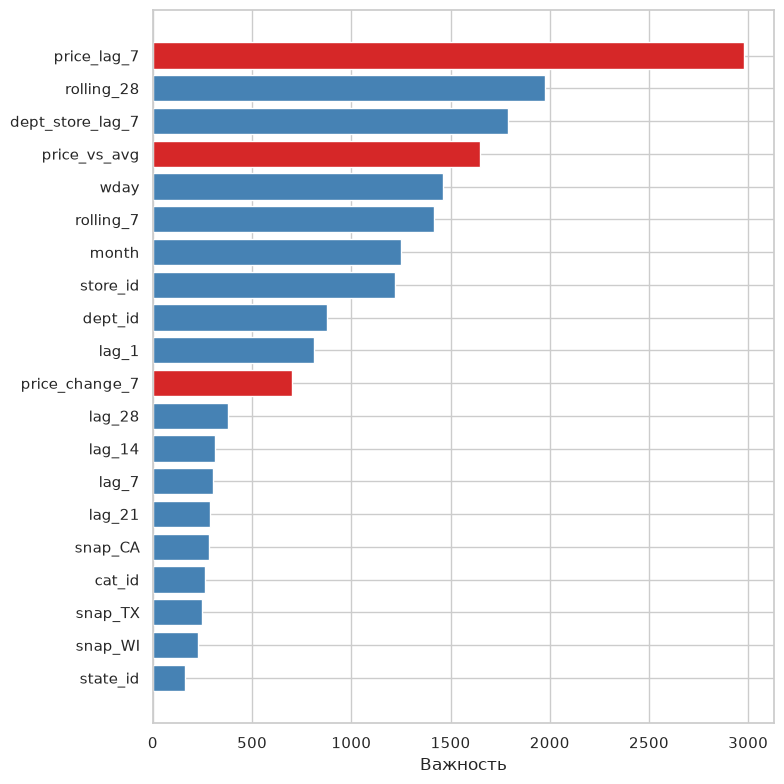

In [33]:
importances_v5 = pd.DataFrame({
    "feature": features_v5,
    "importance": model_v5.feature_importances_,
}).sort_values("importance", ascending=False)

print(importances_v5.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ["#d62728" if "price" in f else "steelblue" for f in importances_v5["feature"]]
ax.barh(importances_v5["feature"], importances_v5["importance"], color=colors)
ax.set_xlabel("Важность")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
# Заполняем NaN в ценовых фичах
df_long["price_vs_avg"] = df_long["price_vs_avg"].fillna(1.0)        # «цена как обычно»
df_long["price_change_7"] = df_long["price_change_7"].fillna(0.0)    # «цена не менялась»
df_long["price_lag_7"] = df_long["price_lag_7"].fillna(df_long["sell_price"])  # «как сейчас»

In [35]:
# Заполняем NaN
df_long["price_vs_avg"] = df_long["price_vs_avg"].fillna(1.0)
df_long["price_change_7"] = df_long["price_change_7"].fillna(0.0)
df_long["price_lag_7"] = df_long["price_lag_7"].fillna(df_long["sell_price"])

gc.collect()
print("NaN после заполнения:")
print(df_long[["price_vs_avg", "price_change_7", "price_lag_7"]].isna().sum())

NaN после заполнения:
price_vs_avg      0
price_change_7    0
price_lag_7       0
dtype: int64


In [36]:
train = df_long[df_long["day_num"] <= 300 - 28].copy()
test  = df_long[df_long["day_num"] >  300 - 28].copy()

# Убираем NaN ТОЛЬКО от rolling (там реально нет истории)
train = train.dropna(subset=["rolling_7", "rolling_28"]).reset_index(drop=True)
test  = test.dropna(subset=["rolling_7", "rolling_28"]).reset_index(drop=True)

print("Train:", train.shape)   # должно быть ~6.5 млн, не 3.5!
print("Test: ", test.shape)
print()
print("Средние продажи в train:", train["sales"].mean().round(3))
print("Средние продажи в test: ", test["sales"].mean().round(3))

Train: (6585840, 26)
Test:  (853720, 26)

Средние продажи в train: 0.849
Средние продажи в test:  0.933


In [37]:
features_v51 = [
    "lag_1", "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_7", "rolling_28",
    "dept_store_lag_7",
    "price_vs_avg", "price_change_7",   # ← убрали price_lag_7
    "wday", "month",
    "snap_CA", "snap_TX", "snap_WI",
    "dept_id", "cat_id", "store_id", "state_id",
]
cat_features = ["dept_id", "cat_id", "store_id", "state_id"]

X_train, y_train = train[features_v51], train["sales"]
X_test, y_test = test[features_v51], test["sales"]

model_v51 = lgb.LGBMRegressor(
    objective="tweedie", n_estimators=300, learning_rate=0.05,
    num_leaves=63, random_state=42, n_jobs=-1,
)

model_v51.fit(X_train, y_train, categorical_feature=cat_features)

preds = np.maximum(model_v51.predict(X_test), 0)
mae_v51 = mean_absolute_error(y_test, preds)

print(f"MAE v3 (без цен): 0.6036")
print(f"MAE v5.1 (цены):  {mae_v51:.4f}")
print(f"Дельта:           {mae_v51 - 0.6036:+.4f}")
print(f"Улучшение:        {1 - mae_v51/0.9327:.1%}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.445339 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1742
[LightGBM] [Info] Number of data points in the train set: 6585840, number of used features: 19
[LightGBM] [Info] Start training from score -0.163114
MAE v3 (без цен): 0.6036
MAE v5.1 (цены):  0.6030
Дельта:           -0.0006
Улучшение:        35.3%


         feature  importance
dept_store_lag_7        3332
            wday        1887
      rolling_28        1876
    price_vs_avg        1739
        store_id        1661
           month        1616
       rolling_7        1276
         dept_id         924
           lag_1         770
  price_change_7         653
         snap_CA         437
         snap_TX         382
          lag_28         360
         snap_WI         345
          cat_id         301
          lag_21         295
          lag_14         272
           lag_7         238
        state_id         236


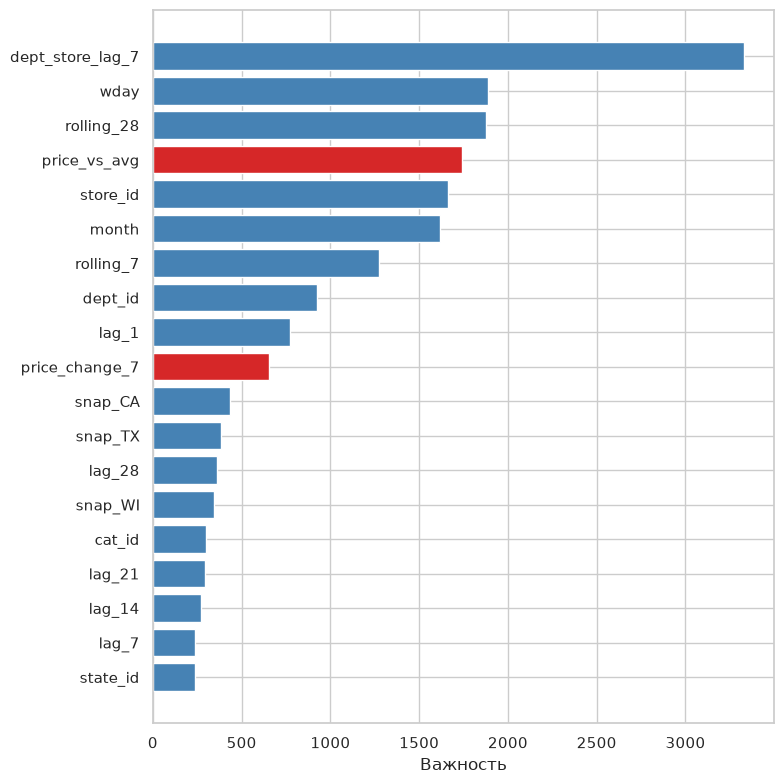

In [38]:
importances = pd.DataFrame({
    "feature": features_v51,
    "importance": model_v51.feature_importances_,
}).sort_values("importance", ascending=False)

print(importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 8))
colors = ["#d62728" if "price" in f else "steelblue" for f in importances["feature"]]
ax.barh(importances["feature"], importances["importance"], color=colors)
ax.set_xlabel("Важность")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.578747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1232
[LightGBM] [Info] Number of data points in the train set: 6585840, number of used features: 17
[LightGBM] [Info] Start training from score -0.163114


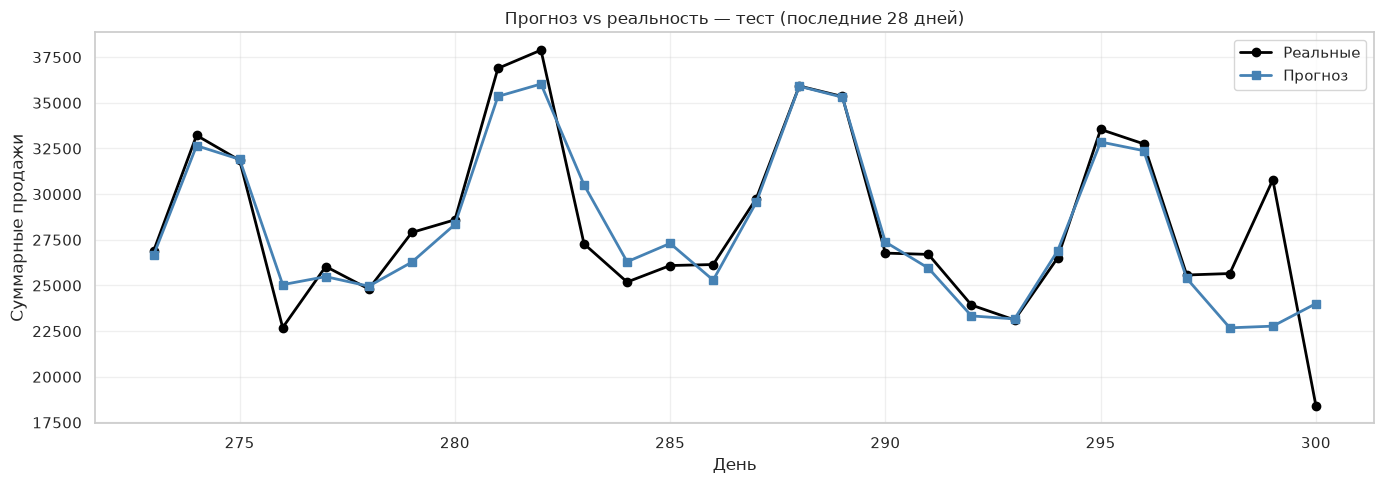

MAE на суммарном ряде: 1,287 продаж в день


In [39]:
# Возвращаемся к v3 (обучаем заново)
features_v3 = [
    "lag_1", "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_7", "rolling_28",
    "dept_store_lag_7",
    "wday", "month",
    "snap_CA", "snap_TX", "snap_WI",
    "dept_id", "cat_id", "store_id", "state_id",
]
cat_features = ["dept_id", "cat_id", "store_id", "state_id"]

train_v3 = df_long[df_long["day_num"] <= 300 - 28].dropna(subset=["rolling_7", "rolling_28"]).reset_index(drop=True)
test_v3  = df_long[df_long["day_num"] >  300 - 28].dropna(subset=["rolling_7", "rolling_28"]).reset_index(drop=True)

X_train = train_v3[features_v3]
X_test  = test_v3[features_v3]
y_train = train_v3["sales"]
y_test  = test_v3["sales"]

model_v3 = lgb.LGBMRegressor(
    objective="tweedie", n_estimators=300, learning_rate=0.05,
    num_leaves=63, random_state=42, n_jobs=-1,
)
model_v3.fit(X_train, y_train, categorical_feature=cat_features)

preds_v3 = np.maximum(model_v3.predict(X_test), 0)
test_v3 = test_v3.copy()
test_v3["preds"] = preds_v3

# Суммарные продажи по дням
daily_actual = test_v3.groupby("day_num")["sales"].sum()
daily_pred   = test_v3.groupby("day_num")["preds"].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_actual.index, daily_actual.values, label="Реальные", color="black", marker="o", linewidth=2)
ax.plot(daily_pred.index, daily_pred.values, label="Прогноз", color="steelblue", marker="s", linewidth=2)
ax.set_xlabel("День")
ax.set_ylabel("Суммарные продажи")
ax.set_title("Прогноз vs реальность — тест (последние 28 дней)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Метрика на суммарном ряде
mae_daily = mean_absolute_error(daily_actual, daily_pred)
print(f"MAE на суммарном ряде: {mae_daily:,.0f} продаж в день")

In [40]:
# Доля нулей для каждого ряда в test
zero_ratio = test_v3.groupby(["item_id", "store_id"], observed=True)["sales"].apply(
    lambda x: (x == 0).mean()
)

# Категории
active_pairs = zero_ratio[zero_ratio < 0.5].index
dead_pairs   = zero_ratio[zero_ratio > 0.9].index

test_v3["is_active"] = test_v3.set_index(["item_id", "store_id"]).index.isin(active_pairs)
test_v3["is_dead"]   = test_v3.set_index(["item_id", "store_id"]).index.isin(dead_pairs)

# MAE по группам
print(f"Всего рядов:                {len(zero_ratio):,}")
print(f"Активных (<50% нулей):      {len(active_pairs):,} ({len(active_pairs)/len(zero_ratio):.1%})")
print(f"Мёртвых (>90% нулей):       {len(dead_pairs):,} ({len(dead_pairs)/len(zero_ratio):.1%})")
print()

mae_all      = mean_absolute_error(test_v3["sales"], test_v3["preds"])
mae_active   = mean_absolute_error(test_v3[test_v3["is_active"]]["sales"], test_v3[test_v3["is_active"]]["preds"])
mae_dead     = mean_absolute_error(test_v3[test_v3["is_dead"]]["sales"],   test_v3[test_v3["is_dead"]]["preds"])

print(f"MAE на всех рядах:     {mae_all:.4f}")
print(f"MAE на активных:       {mae_active:.4f}")
print(f"MAE на мёртвых:        {mae_dead:.4f}")

Всего рядов:                30,490
Активных (<50% нулей):      6,655 (21.8%)
Мёртвых (>90% нулей):       16,908 (55.5%)

MAE на всех рядах:     0.6036
MAE на активных:       2.0138
MAE на мёртвых:        0.0218


In [41]:
import joblib

# Сохраняем модель и списки признаков
joblib.dump(model_v3, "/app/m5_lgbm_v3.joblib")
joblib.dump(features_v3, "/app/m5_features_v3.joblib")
joblib.dump(cat_features, "/app/m5_cat_features.joblib")

print("Сохранено:")
print("  - m5_lgbm_v3.joblib")
print("  - m5_features_v3.joblib")
print("  - m5_cat_features.joblib")

Сохранено:
  - m5_lgbm_v3.joblib
  - m5_features_v3.joblib
  - m5_cat_features.joblib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42

In [ ]:
DATA = Path("/app/data/m5")

df = pd.read_csv(DATA / "sales_train_evaluation.csv")
calendar = pd.read_csv(DATA / "calendar.csv")
prices = pd.read_csv(DATA / "sell_prices.csv")

day_cols = [c for c in df.columns if c.startswith("d_")]

long = df.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    value_vars=day_cols,
    var_name="d",
    value_name="sales",
)

long = long.merge(
    calendar[["d", "date", "wm_yr_wk", "weekday", "month", "year",
              "event_name_1", "event_type_1",
              "snap_CA", "snap_TX", "snap_WI"]],
    on="d", how="left",
)

long = long.merge(
    prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left",
)

long["date"] = pd.to_datetime(long["date"])
print("Размер long:", long.shape)
print(long.head())